In [ ]:
from utility.plot_spectrum import plot_spectrum
from utility.my_colors import palette_dark

import pandas as pd
import matplotlib.pyplot as plt
import json


desi_search_log_path = "data/local/hamann-objects-desi-search-log.json"
sdss_search_log_path = "data/local/hamann-objects-sdss-search-log.json"
matched_desi_spectra_path = "data/local/matched_desi_spectra.json"
hamann_sdss_spectra_path = "data/local/hamann_sdss_spectra.json"


settings = {
        'font.size':16,
        'xtick.direction':'in', 
        'xtick.minor.visible':True,
        'xtick.top':True,
        'ytick.direction':'in', 
        'ytick.minor.visible':True,
        'ytick.right':True,
        'xtick.major.size':6.0,
        'xtick.minor.size':4.0,
        'ytick.major.size':6.0,
        'ytick.minor.size':4.0,
        'legend.frameon':False
    }

plt.rcParams.update(**settings)

In [22]:
pd.read_json("data/relevant_erq_data.json")

,sdss_name,z_dr12,rew,fwhm,kt80,specid,redshift,redshift_warning,wavelength,flux,ivar,absorption_detected,absorption_relevant
0,000610.67+121501.2,2.309943,106.996659,4540.061012,0.372288,6360287837779417088,2.309787,0,"[3553.8574198608, 3554.6758199907, 3555.494408...","[1.9252539873, 1.9251964092, 1.3102685213, 0.6...","[0.0, 0.11758627, 0.0, 0.19981963930000002, 0....",False,0.0
1,000746.19+122223.9,2.429000,219.633801,2432.830081,0.284162,6360267496814303232,2.433351,0,"[3553.8574198608, 3554.6758199907, 3555.494408...","[-5.924967289, -5.9247941971, 3.1096043587, 12...","[0.0, 0.11920769510000001, 0.0, 0.0926503986, ...",False,1.0
2,002400.25+245031.9,2.809255,143.689957,3523.281699,0.372201,7069533316387723264,2.789841,4,"[3558.7706484879, 3559.5901800608, 3560.409900...","[-0.8786045313, -0.8787579536000001, 0.1475744...","[0.0, 0.0552793145, 0.0, 0.048356846, 0.047023...",False,1.0
3,004713.21+264024.7,2.563943,100.506344,3685.427543,0.325082,7077626822452860928,2.553878,0,"[3561.2298094276, 3562.0499073084, 3562.870194...","[-1.7795865536000002, -1.7798964977, -1.780206...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",True,1.0
4,005044.95-021217.6,2.254000,147.225015,4343.057592,0.193256,4920452066097518592,2.253475,0,"[3553.0392081527, 3553.8574198608, 3554.675819...","[1.8903125525000002, 1.8905686140000002, 1.890...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",True,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
92,223754.52+065026.6,2.608809,140.676812,1390.574742,0.356129,5694835917824743424,2.614897,0,"[3561.2298094276, 3562.0499073084, 3562.870194...","[14.607211113, -22.7902507782, 20.6671199799, ...","[0.09246767310000001, 0.1343497932, 0.12748730...",False,1.0
93,225438.30+232714.5,3.087494,415.244897,4411.577590,0.358143,7417535898320132096,3.087466,0,"[3568.6174928348, 3569.4392919885, 3570.261280...","[-1.3009853363000001, -0.3360394239, -0.240143...","[0.2848583758, 0.26905199890000003, 0.28210353...",False,1.0
94,232326.17-010033.1,2.356070,255.993179,3989.269919,0.370693,4740064262789289984,2.350765,0,"[3564.5113342624, 3565.3321878293, 3566.153230...","[7.0590491295, -4.7015686035, 7.8777022362, 1....","[0.0343443416, 0.1265157163, 0.126755625, 0.13...",False,0.0
95,232828.47+044346.8,2.563872,358.595759,1583.693351,0.352179,4822392127110797312,2.568358,0,"[3553.0392081527, 3553.8574198608, 3554.675819...","[1.856464982, 1.8564176559, 1.8563705683, 1.85...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",True,1.0


In [ ]:
desi_log = pd.read_json(desi_search_log_path)[["SDSS_id","best_match_id"]]
desi_log = desi_log.rename(columns={"best_match_id":"desi_match"})
desi_spectra = pd.read_json(matched_desi_spectra_path)
desi_spectra["targetid"] = desi_spectra["targetid"].astype("string")
desi_spectra = desi_spectra.merge(desi_log,left_on="targetid",right_on="desi_match")

sdss_log = pd.read_json(sdss_search_log_path)[["SDSS_id","best_match_id"]]
sdss_log = sdss_log.rename(columns={"best_match_id":"boss_match"})
sdss_spectra = pd.read_json(hamann_sdss_spectra_path).merge(sdss_log,left_on="specid",right_on="boss_match")

spectra_combined = sdss_spectra.merge(desi_spectra,on="SDSS_id", suffixes=["_sdss","_desi"])

spectra_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   redshift_warning_sdss  49 non-null     int64  
 1   sparcl_id_sdss         49 non-null     object 
 2   specid_sdss            49 non-null     int64  
 3   spectype_sdss          49 non-null     object 
 4   redshift_sdss          49 non-null     float64
 5   ivar_sdss              49 non-null     object 
 6   flux_sdss              49 non-null     object 
 7   wavelength_sdss        49 non-null     object 
 8   _dr_sdss               49 non-null     object 
 9   SDSS_id                49 non-null     object 
 10  boss_match             49 non-null     int64  
 11  redshift_warning_desi  49 non-null     int64  
 12  targetid               49 non-null     object 
 13  sparcl_id_desi         49 non-null     object 
 14  specid_desi            49 non-null     int64  
 15  spectype

---------------------------------------
---------------------------------------

SDSS: J134417.34+445459.4


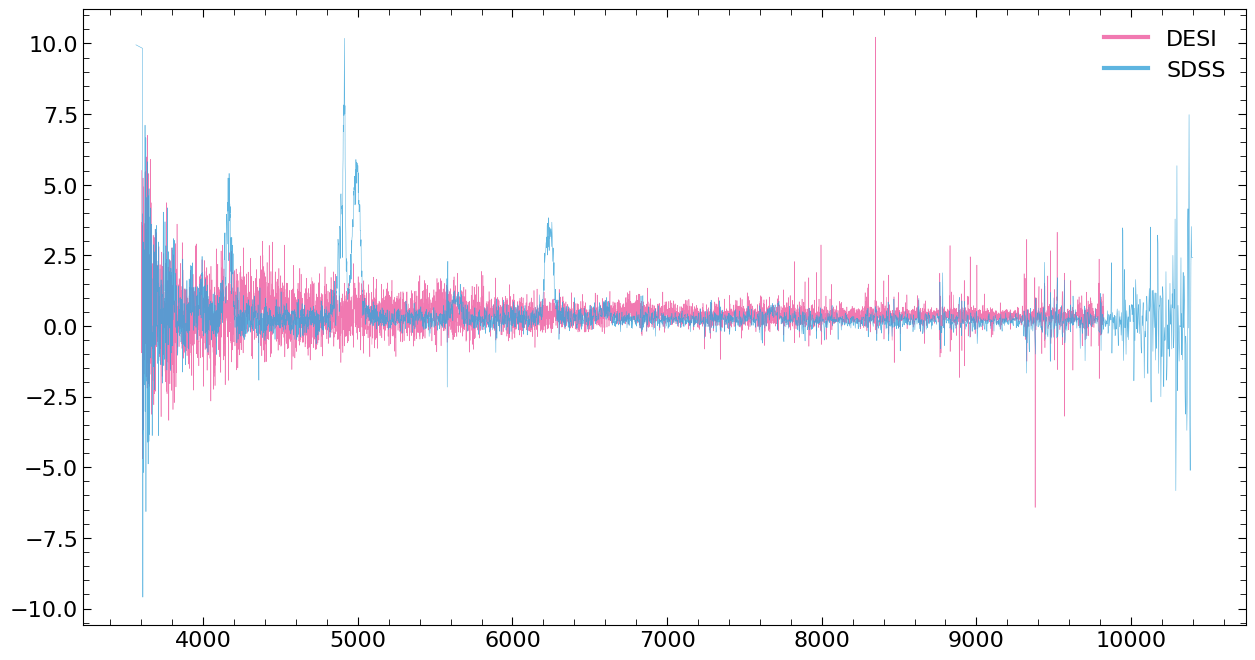

---------------------------------------
---------------------------------------

SDSS: J130936.14+560111.3


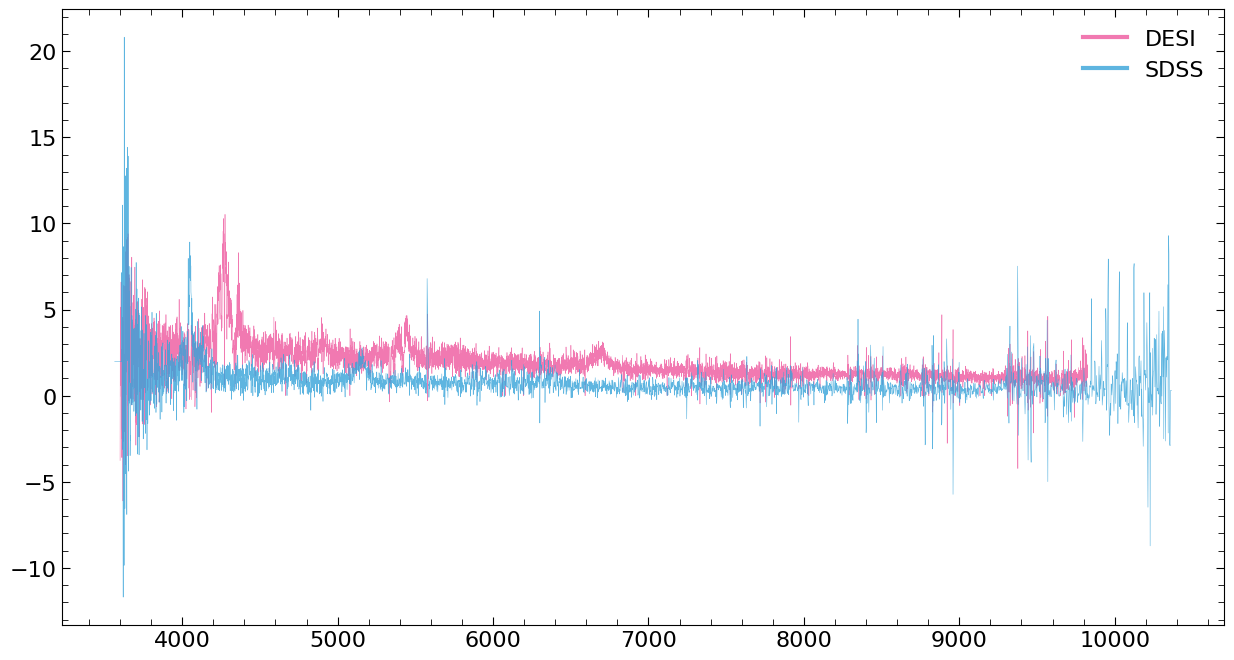

---------------------------------------
---------------------------------------

SDSS: J165202.64+172852.3


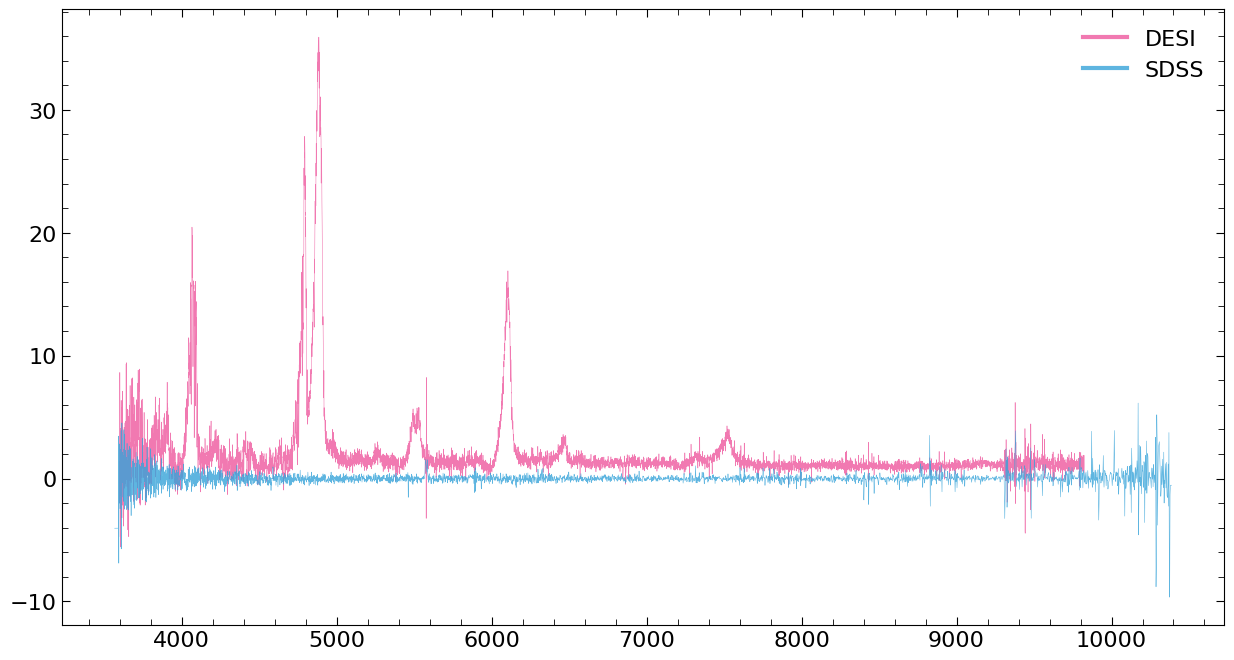

---------------------------------------
---------------------------------------

SDSS: J165202.64+172852.3


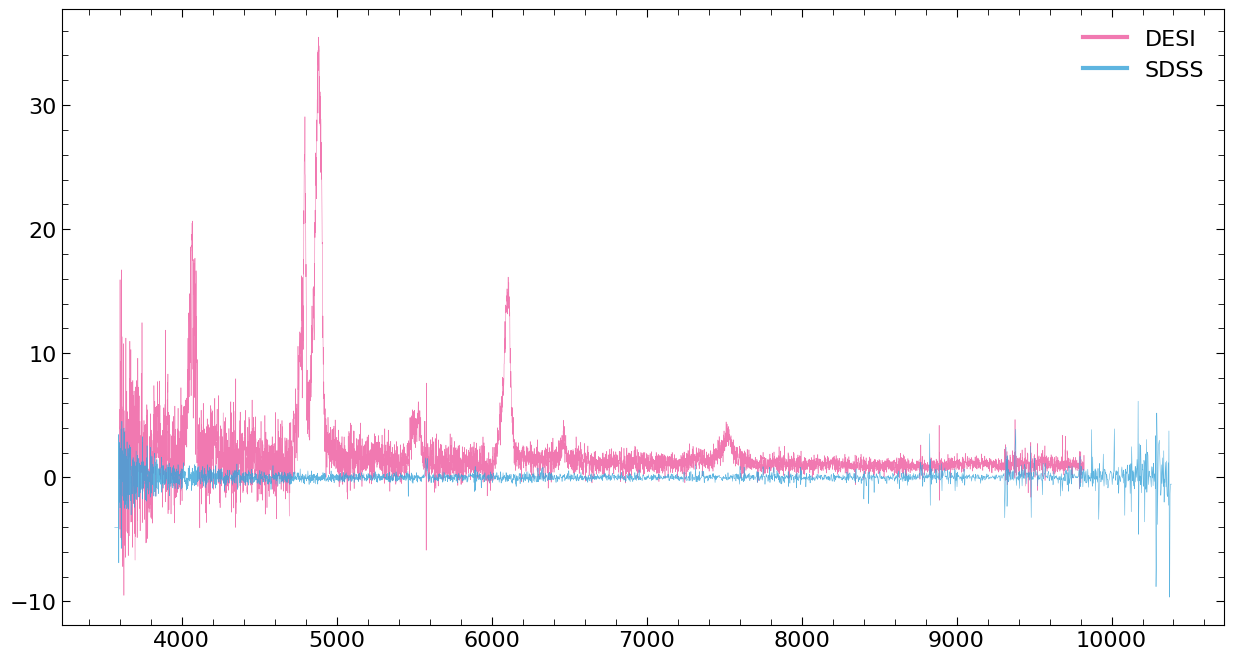

---------------------------------------
---------------------------------------

SDSS: J005044.95-021217.6


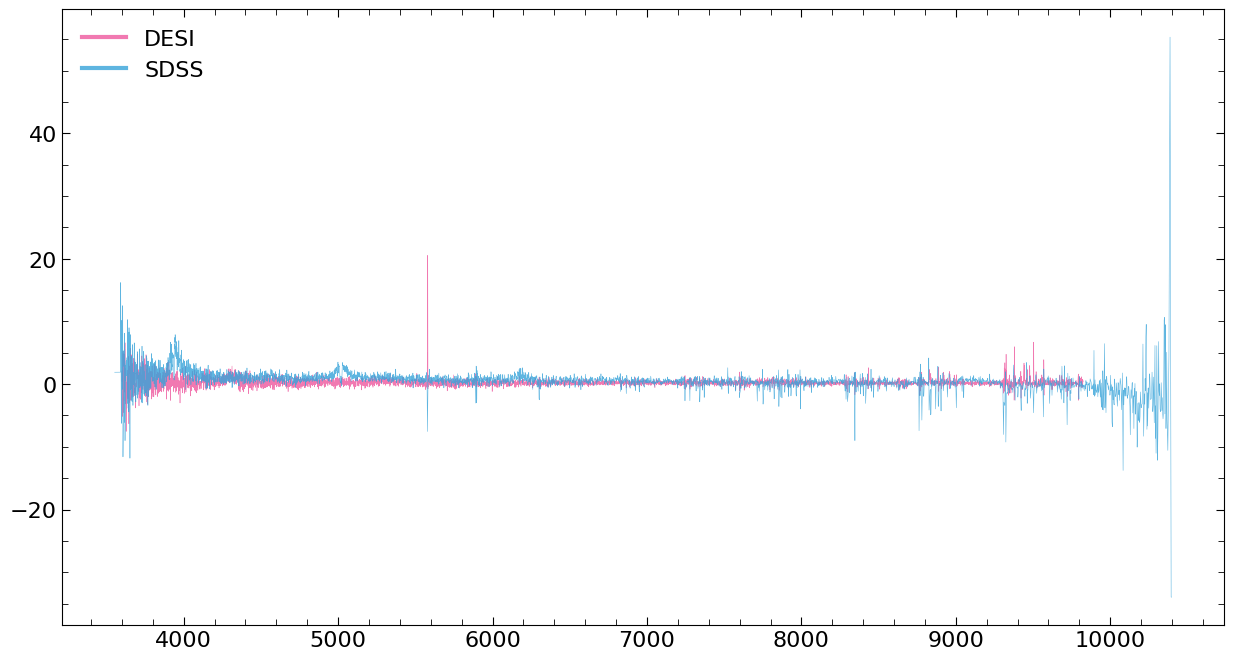

---------------------------------------
---------------------------------------

SDSS: J232326.17-010033.1


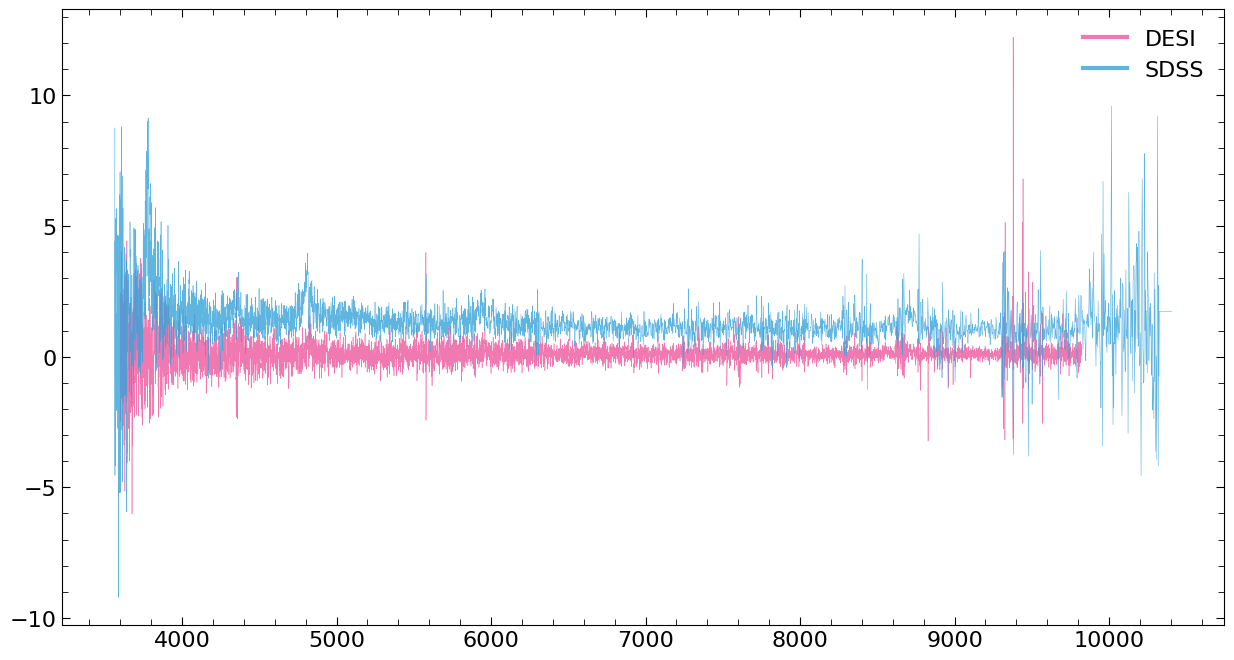

---------------------------------------
---------------------------------------

SDSS: J020932.15+312202.7


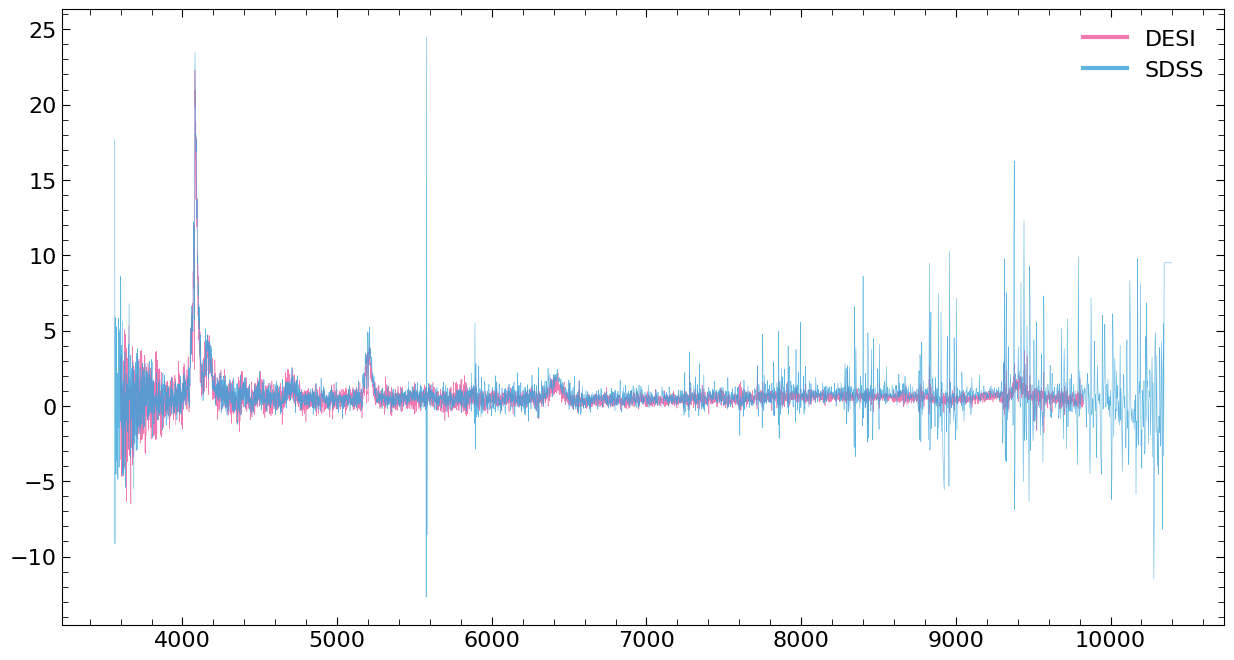

---------------------------------------
---------------------------------------

SDSS: J014111.13-031852.5


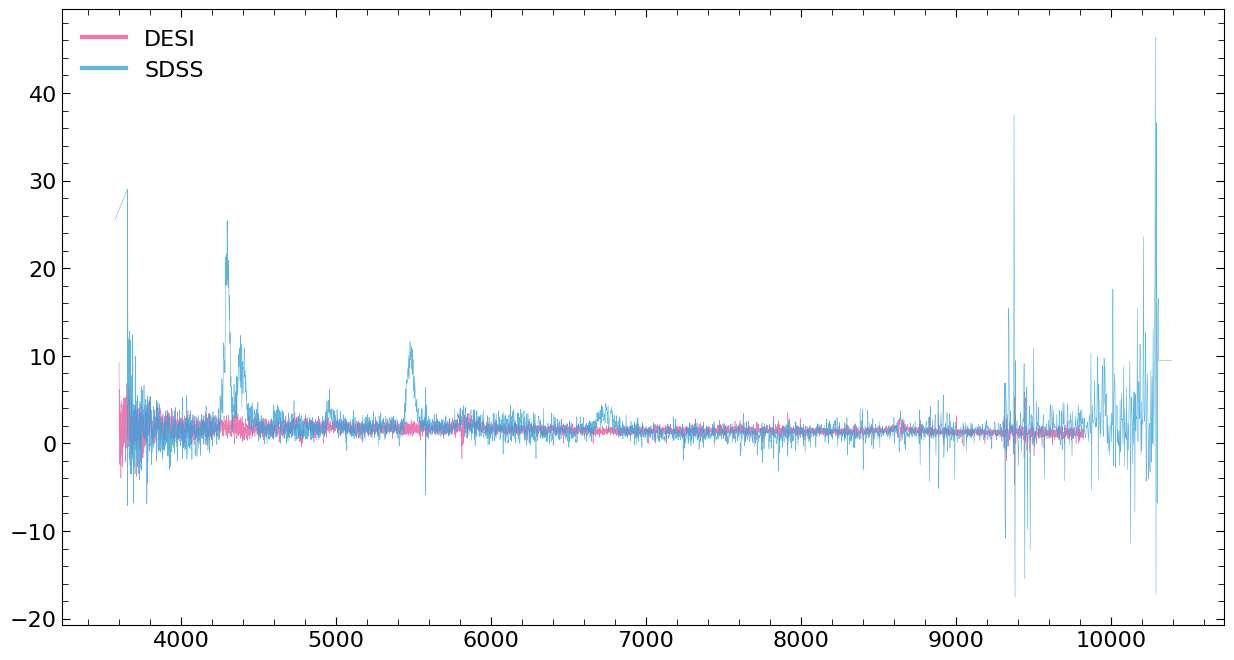

---------------------------------------
---------------------------------------

SDSS: J002400.25+245031.9


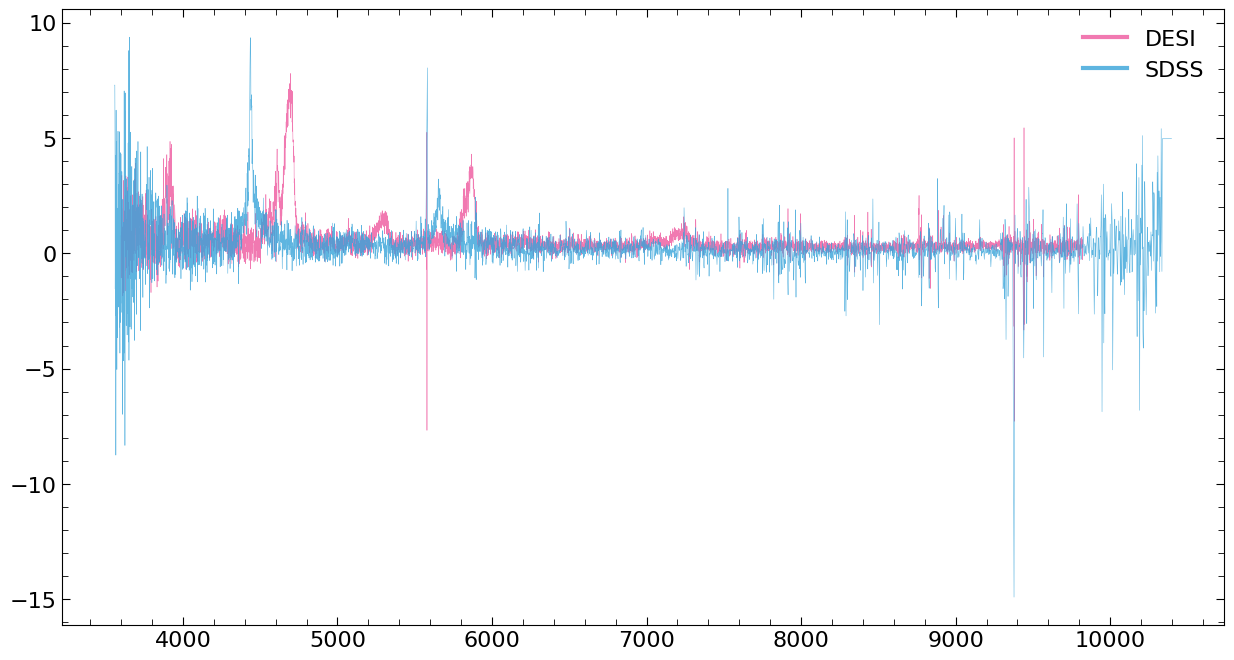

---------------------------------------
---------------------------------------

SDSS: J110202.68-000752.7


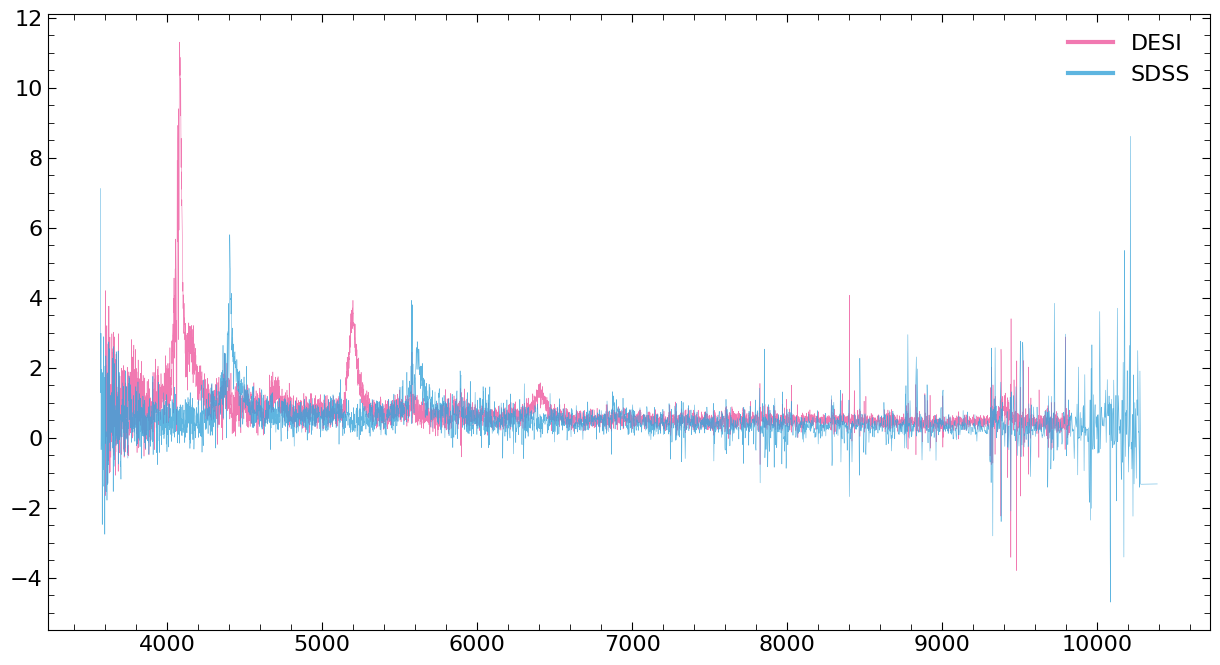

---------------------------------------
---------------------------------------

SDSS: J160431.55+563354.2


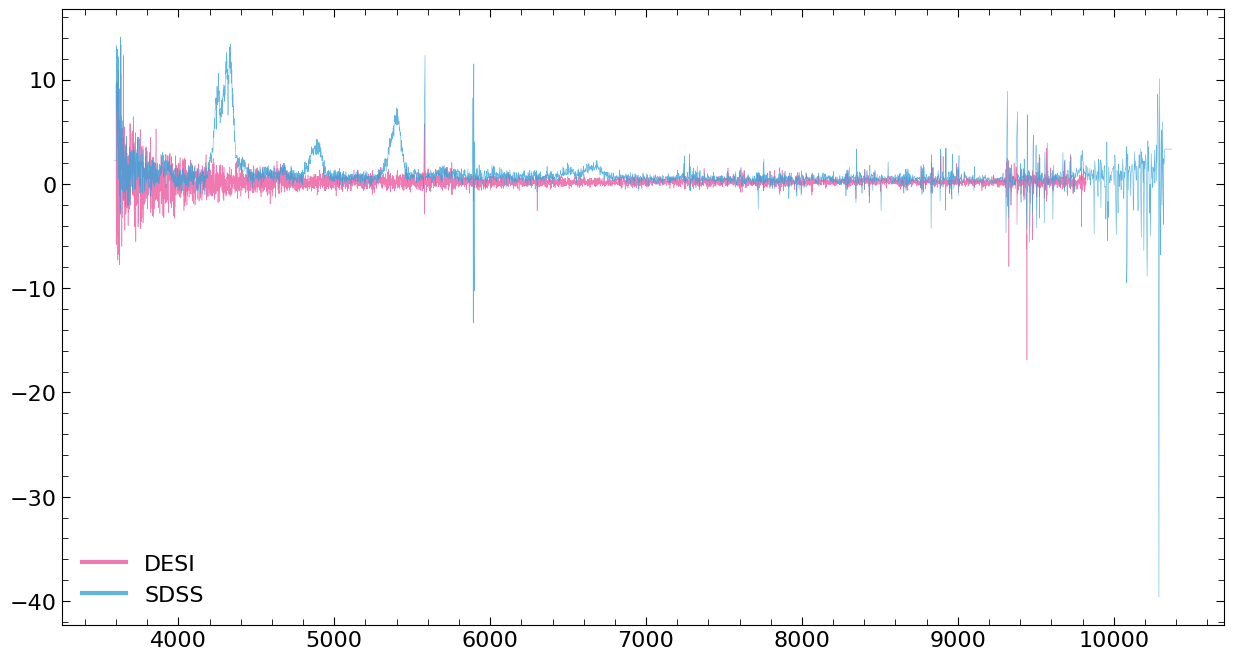

---------------------------------------
---------------------------------------

SDSS: J083448.48+015921.1


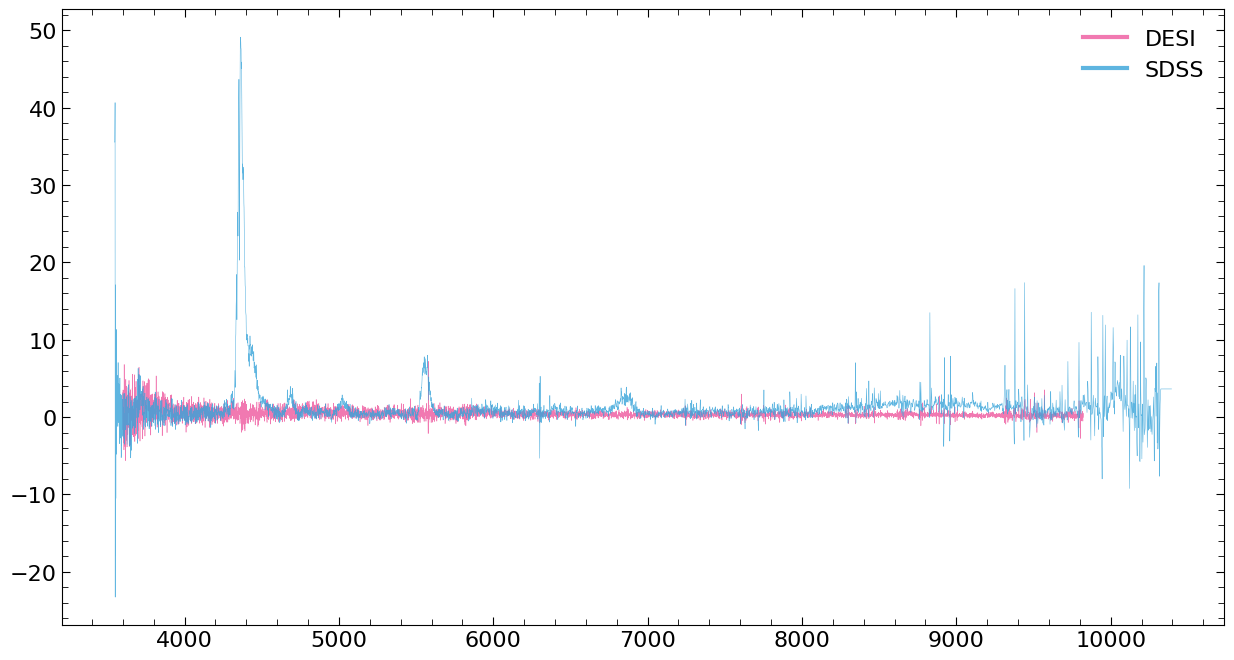

---------------------------------------
---------------------------------------

SDSS: J005233.24-055653.5


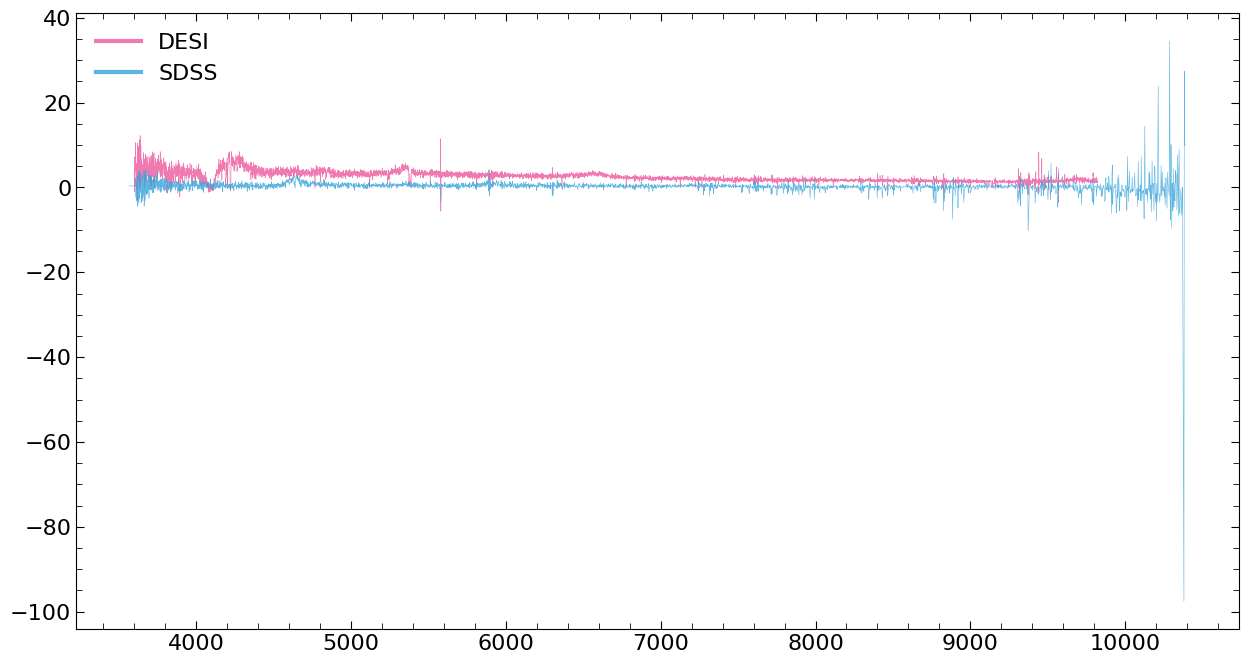

---------------------------------------
---------------------------------------

SDSS: J223754.52+065026.6


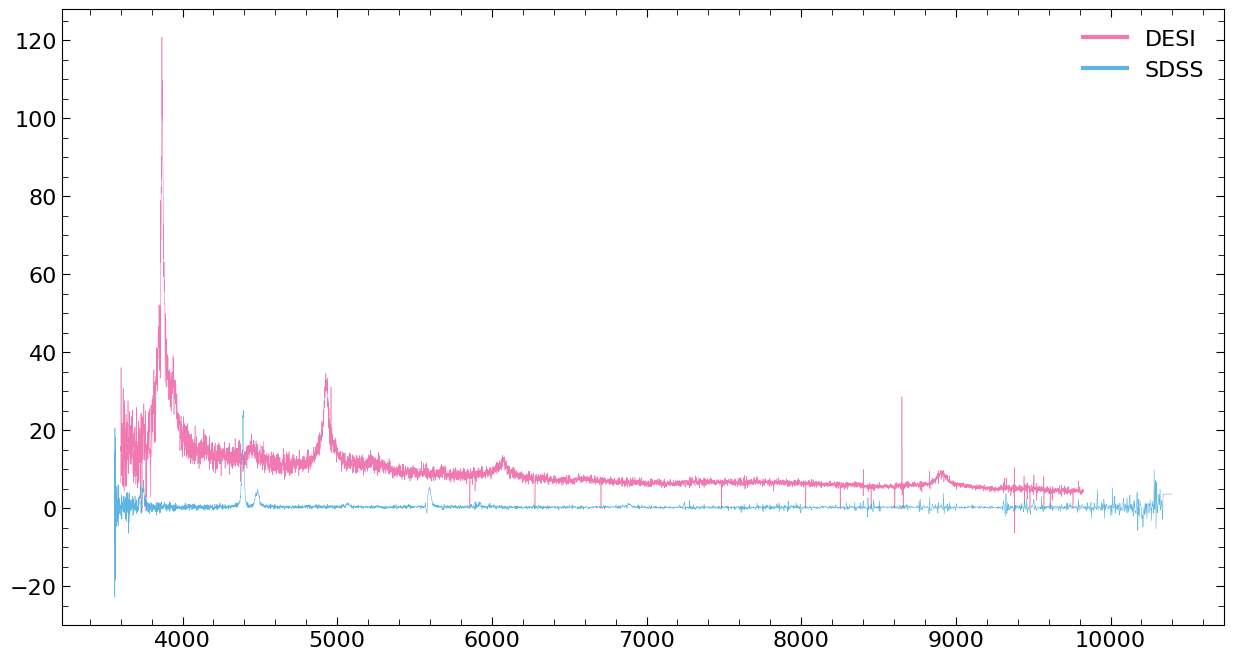

---------------------------------------
---------------------------------------

SDSS: J221524.00-005643.8


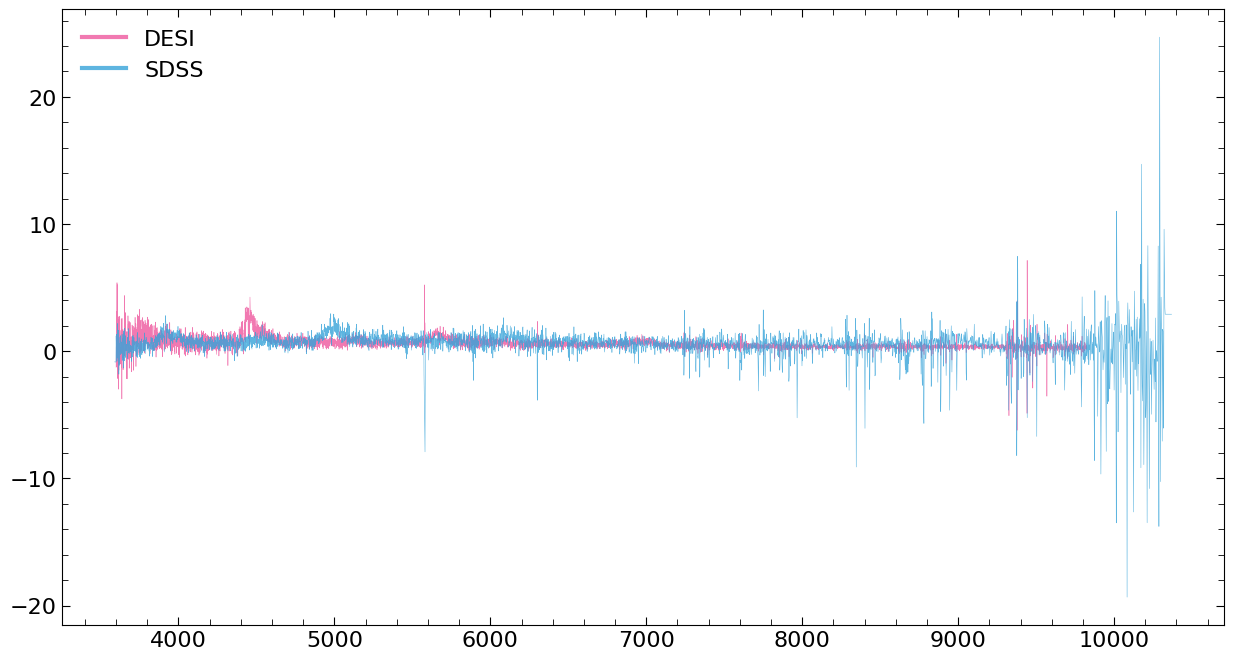

---------------------------------------
---------------------------------------

SDSS: J085451.11+173009.1


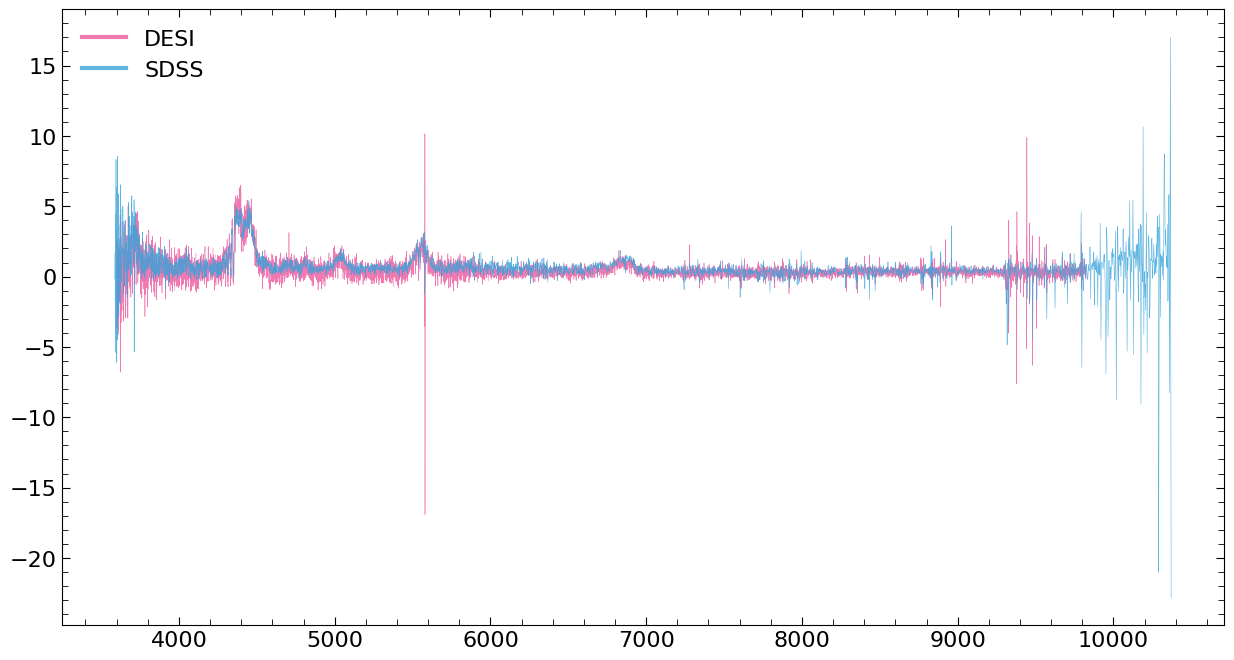

---------------------------------------
---------------------------------------

SDSS: J134001.90+322155.9


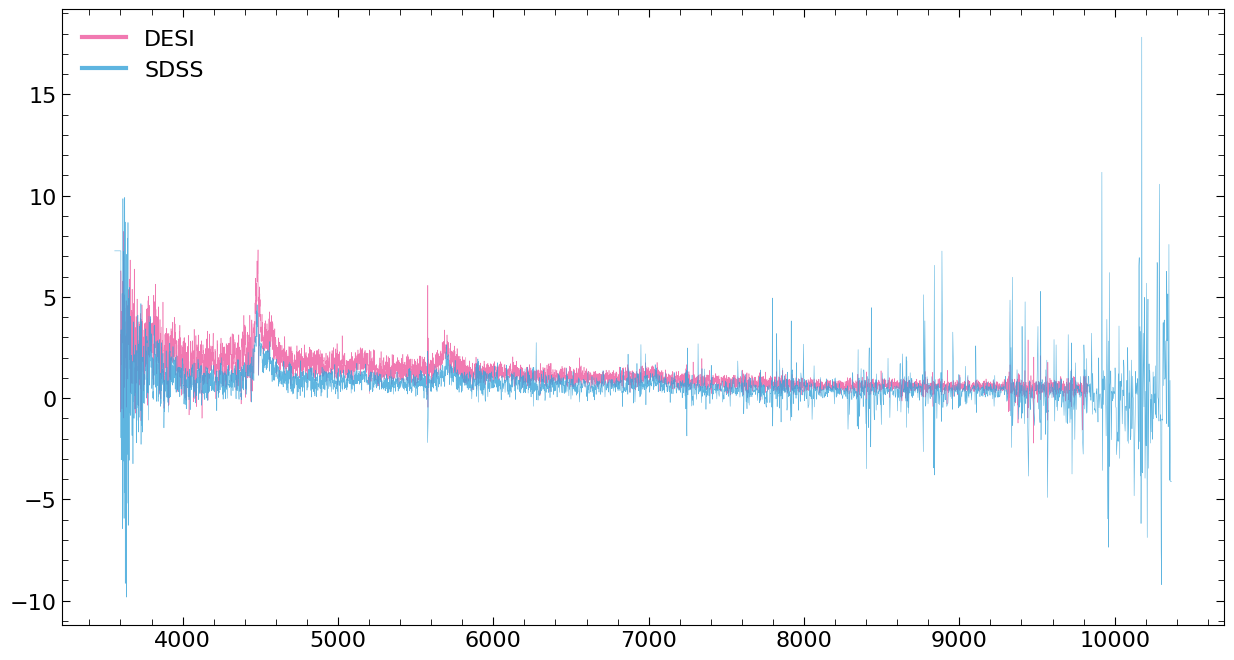

---------------------------------------
---------------------------------------

SDSS: J104611.50+024351.6


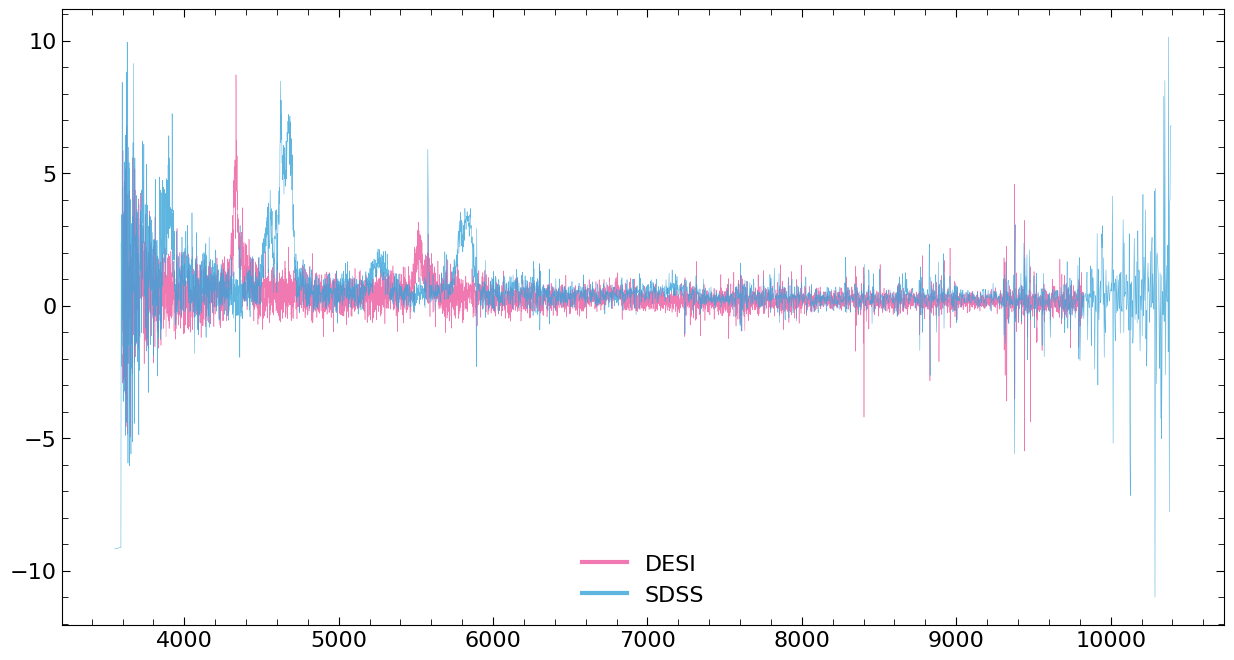

---------------------------------------
---------------------------------------

SDSS: J102541.78+245424.2


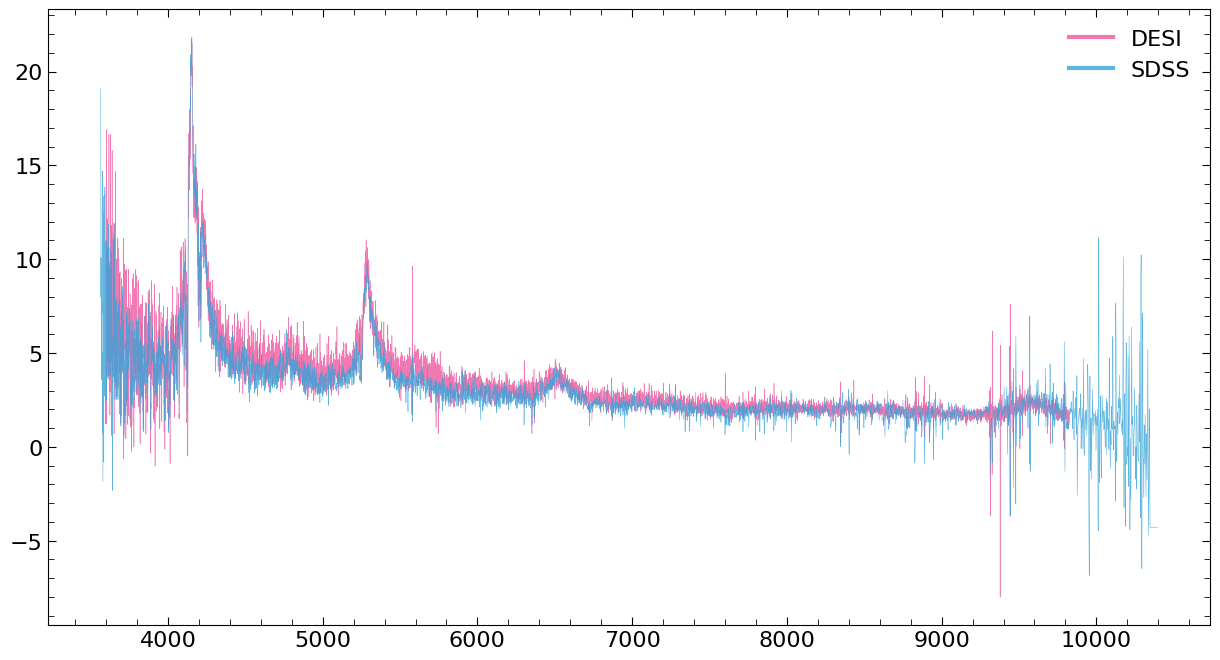

---------------------------------------
---------------------------------------

SDSS: J082649.30+163945.2


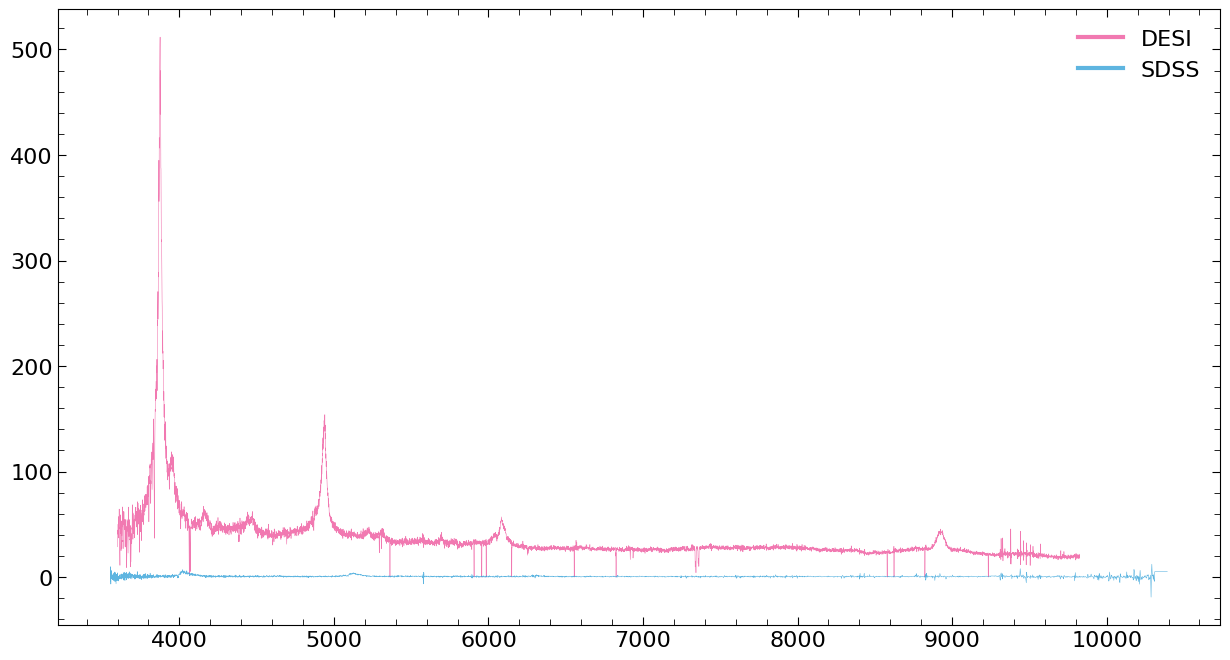

---------------------------------------
---------------------------------------

SDSS: J082649.30+163945.2


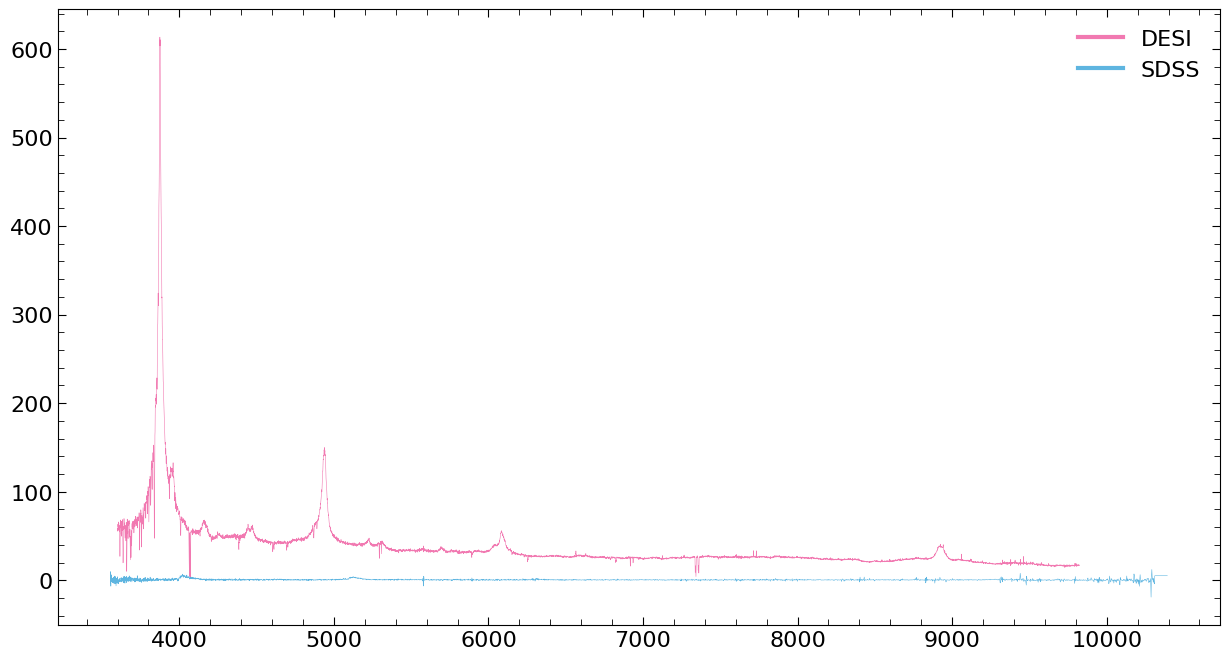

---------------------------------------
---------------------------------------

SDSS: J125019.46+630638.6


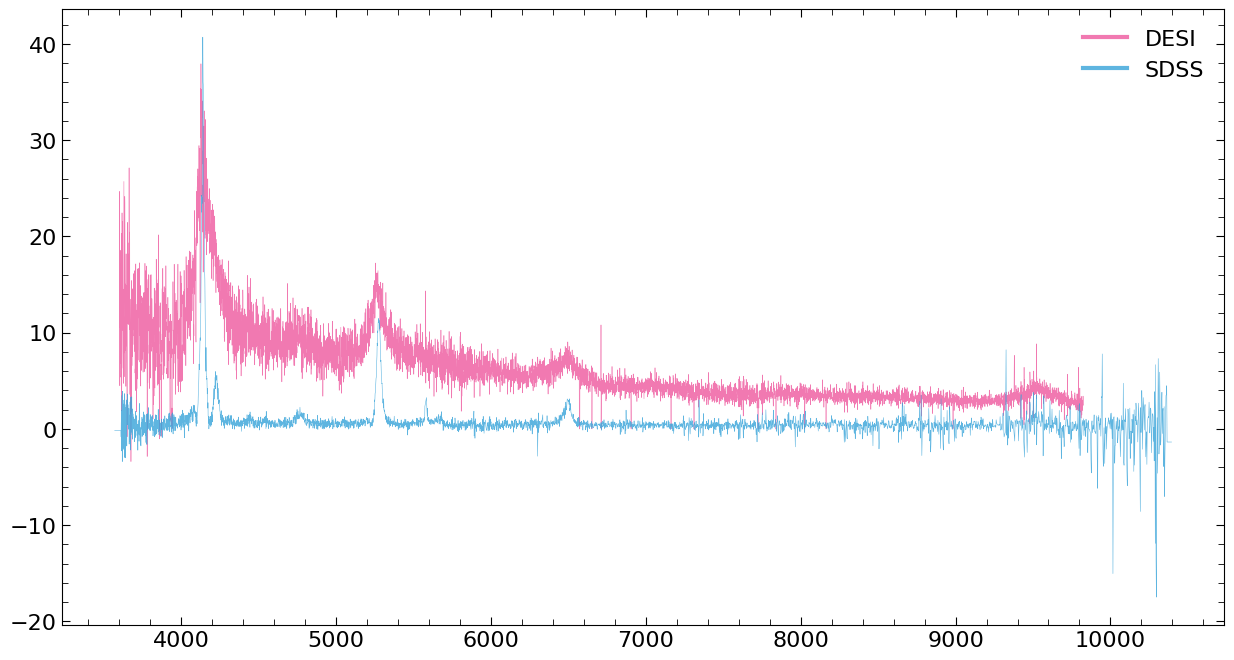

---------------------------------------
---------------------------------------

SDSS: J131047.78+322518.3


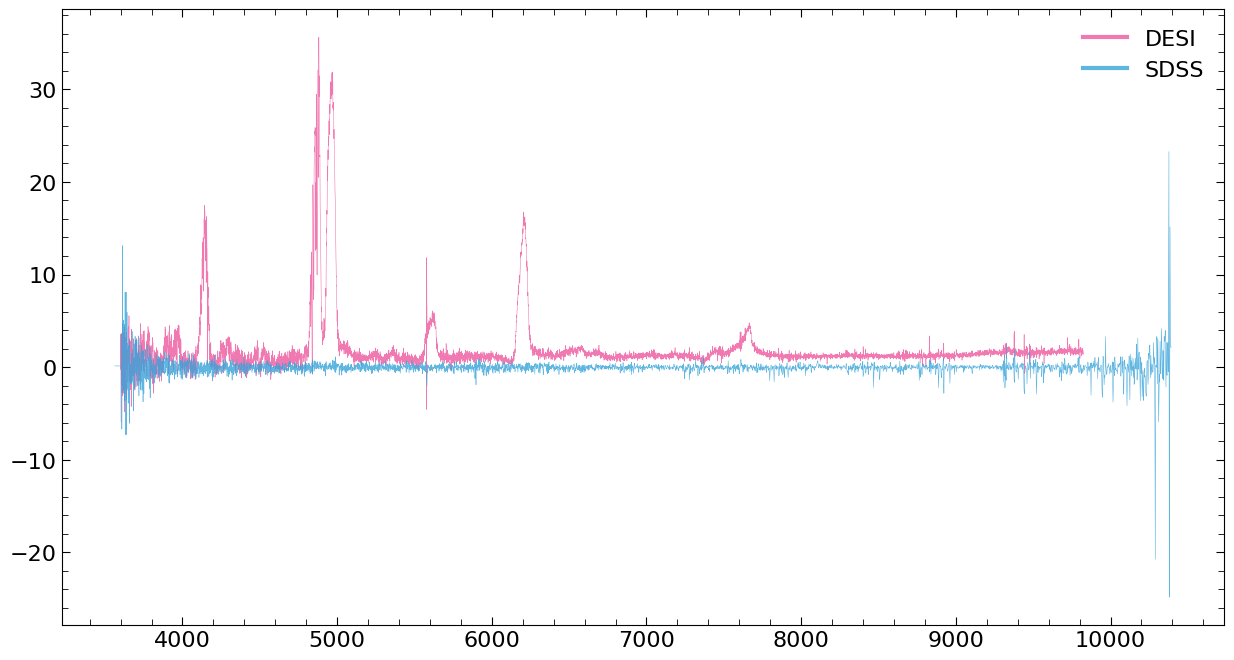

---------------------------------------
---------------------------------------

SDSS: J084447.66+462338.7


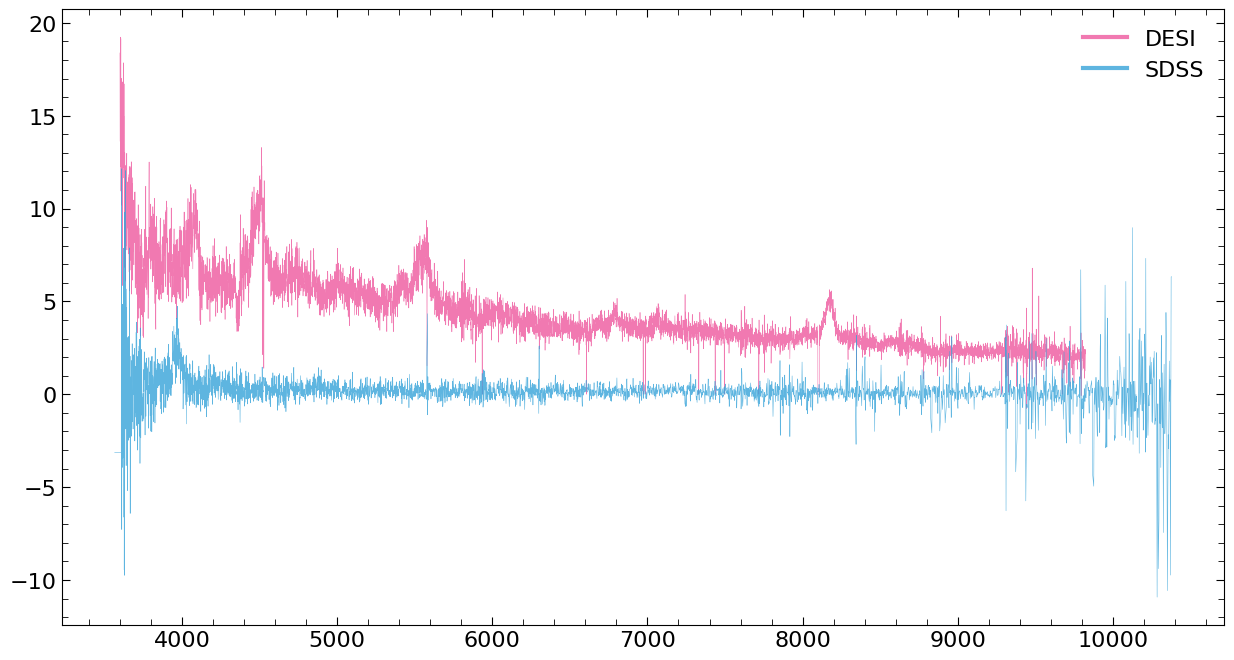

---------------------------------------
---------------------------------------

SDSS: J082653.42+054247.3


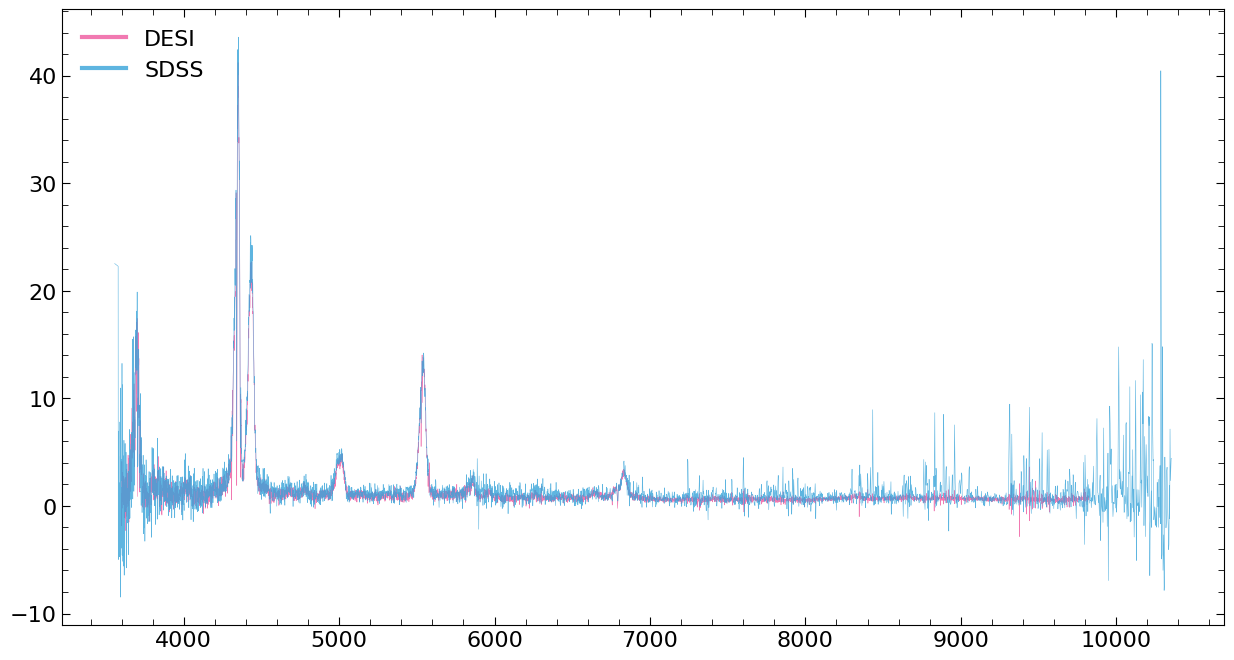

---------------------------------------
---------------------------------------

SDSS: J103146.53+290324.1


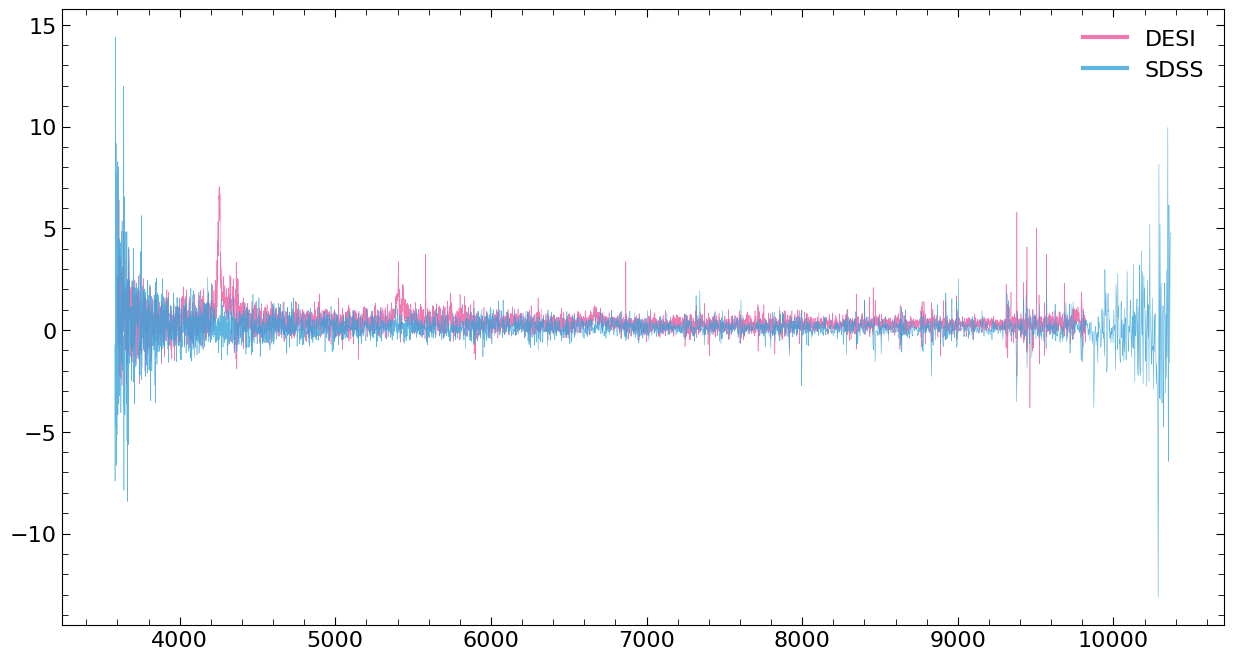

---------------------------------------
---------------------------------------

SDSS: J102447.32-013633.8


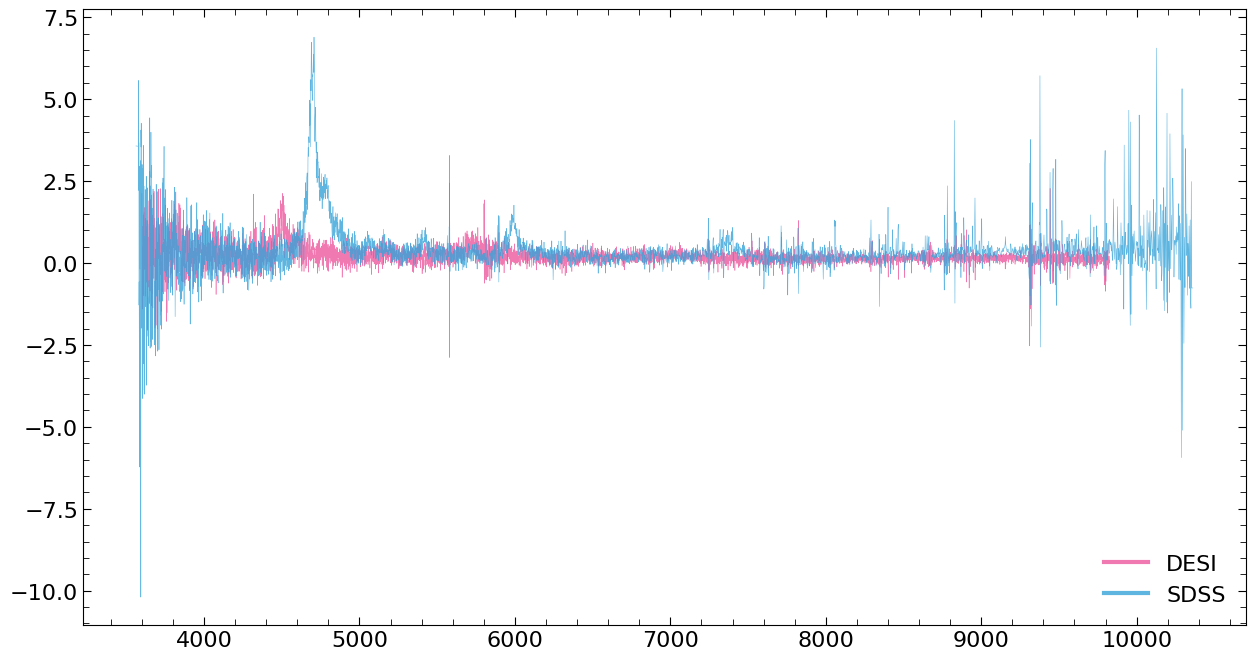

---------------------------------------
---------------------------------------

SDSS: J222421.63+174041.2


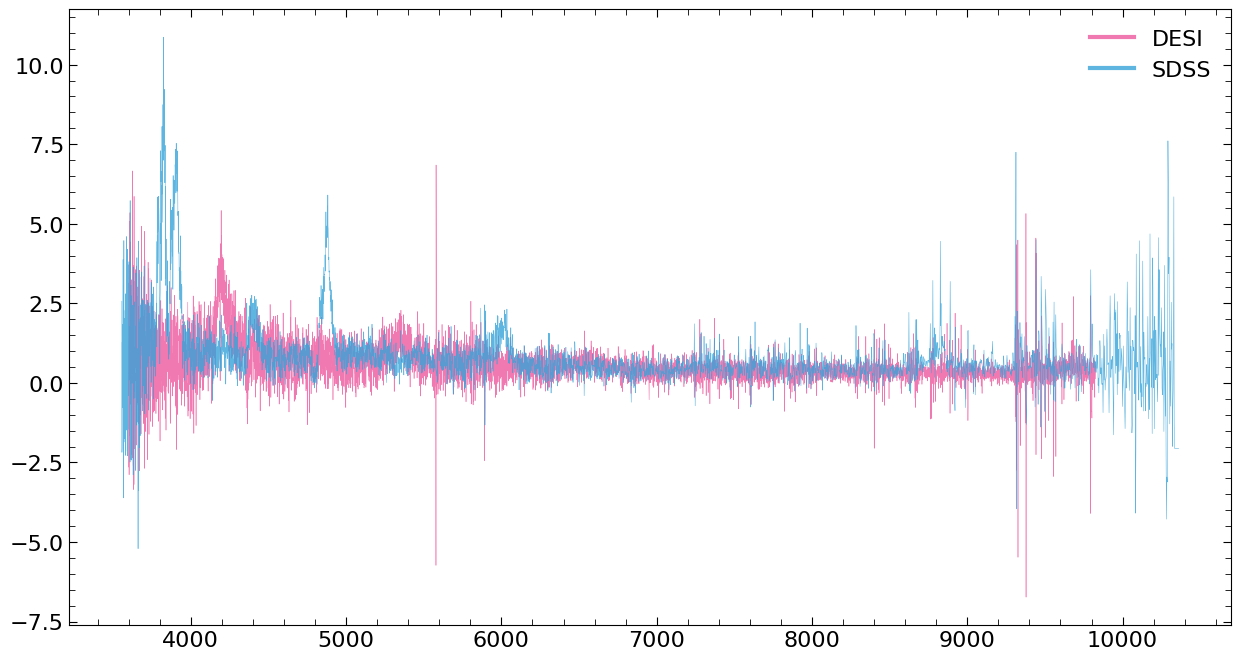

---------------------------------------
---------------------------------------

SDSS: J091508.45+561316.0


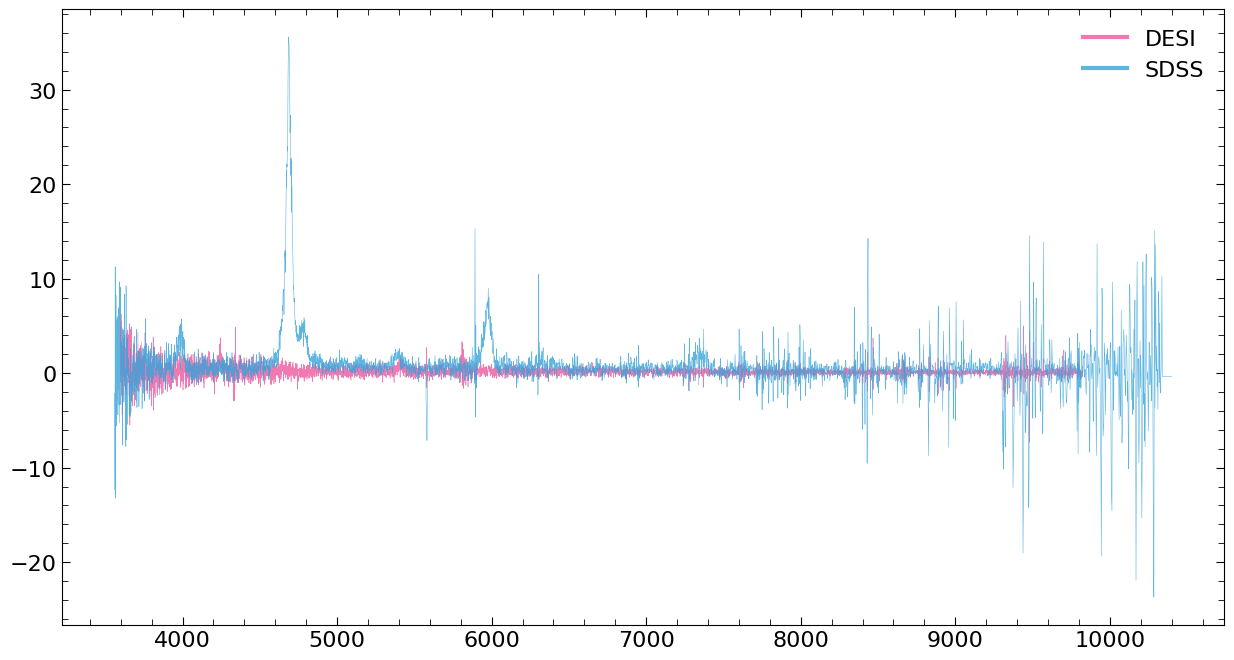

---------------------------------------
---------------------------------------

SDSS: J134450.51+140139.2


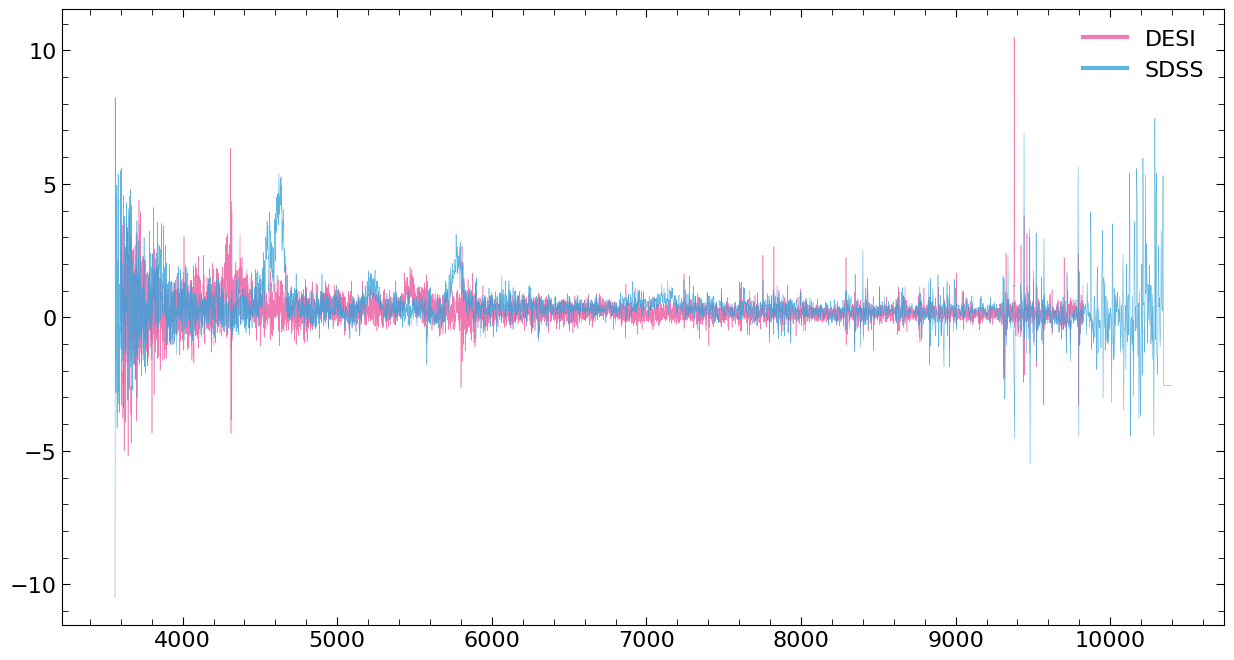

---------------------------------------
---------------------------------------

SDSS: J232828.47+044346.8


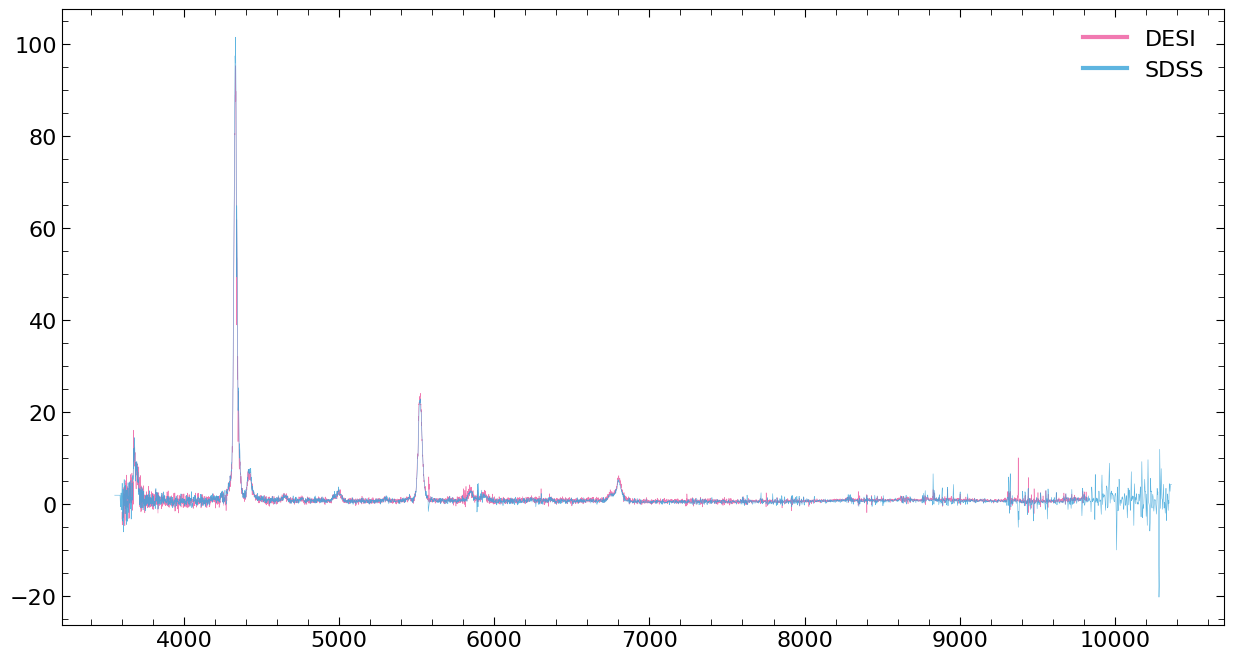

---------------------------------------
---------------------------------------

SDSS: J104718.35+484433.8


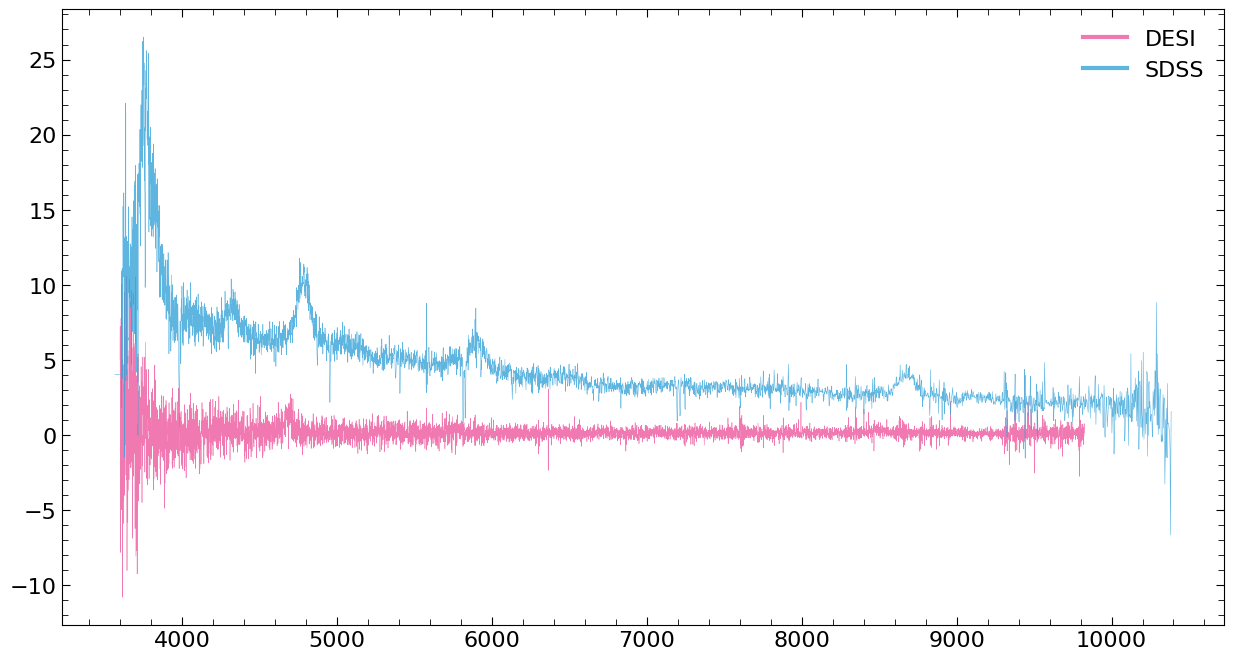

---------------------------------------
---------------------------------------

SDSS: J170558.64+273624.7


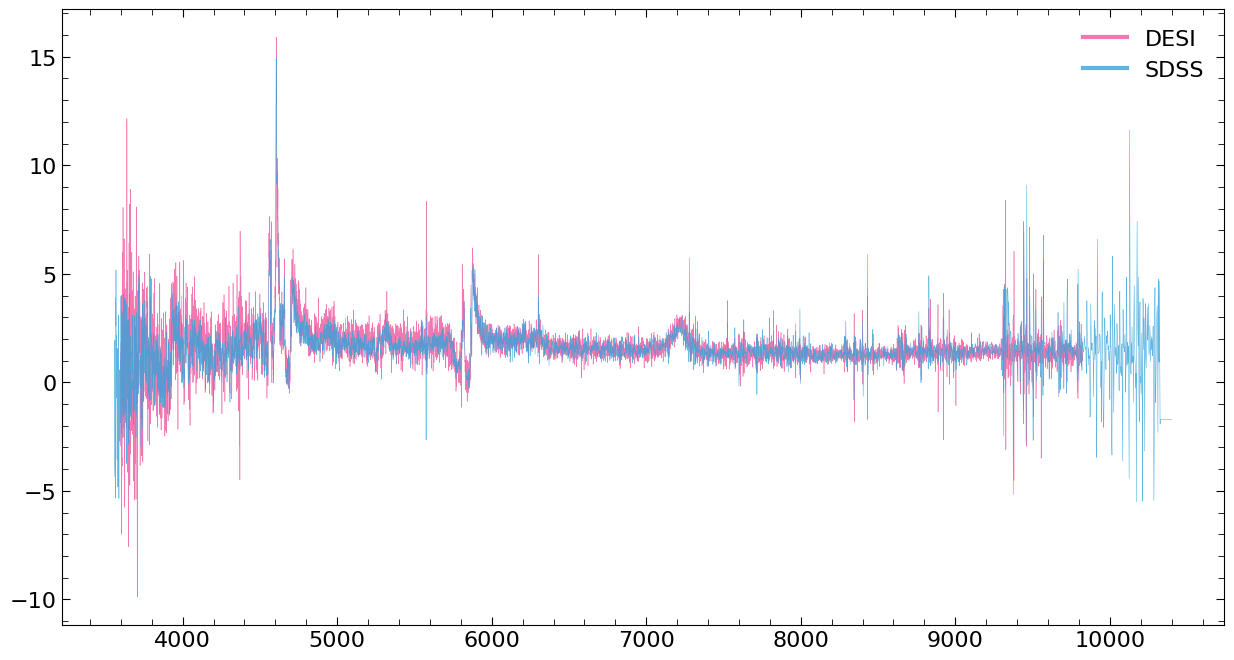

---------------------------------------
---------------------------------------

SDSS: J111355.72+451452.6


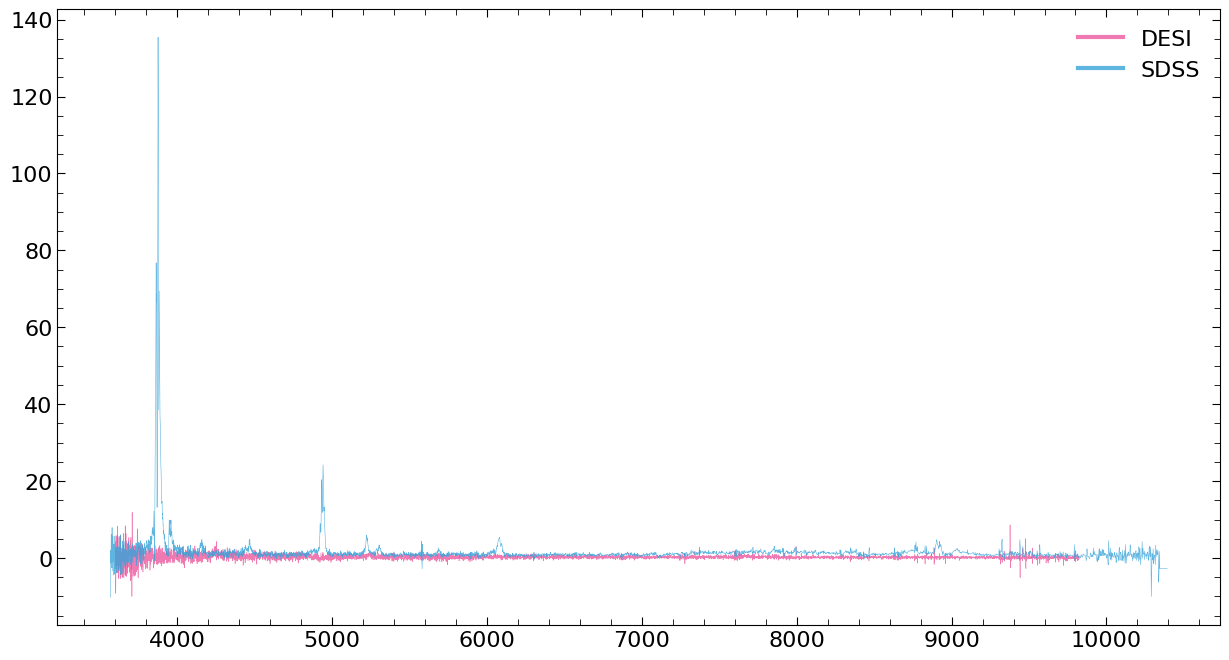

---------------------------------------
---------------------------------------

SDSS: J153107.14+105825.8


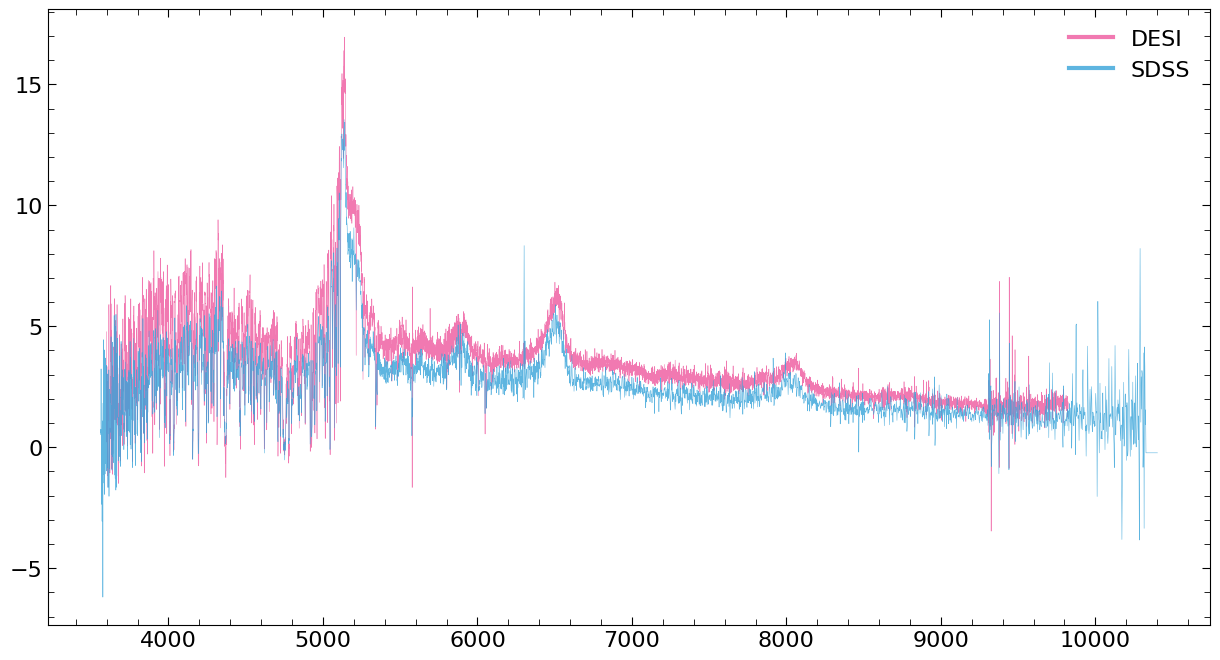

---------------------------------------
---------------------------------------

SDSS: J082536.31+200040.3


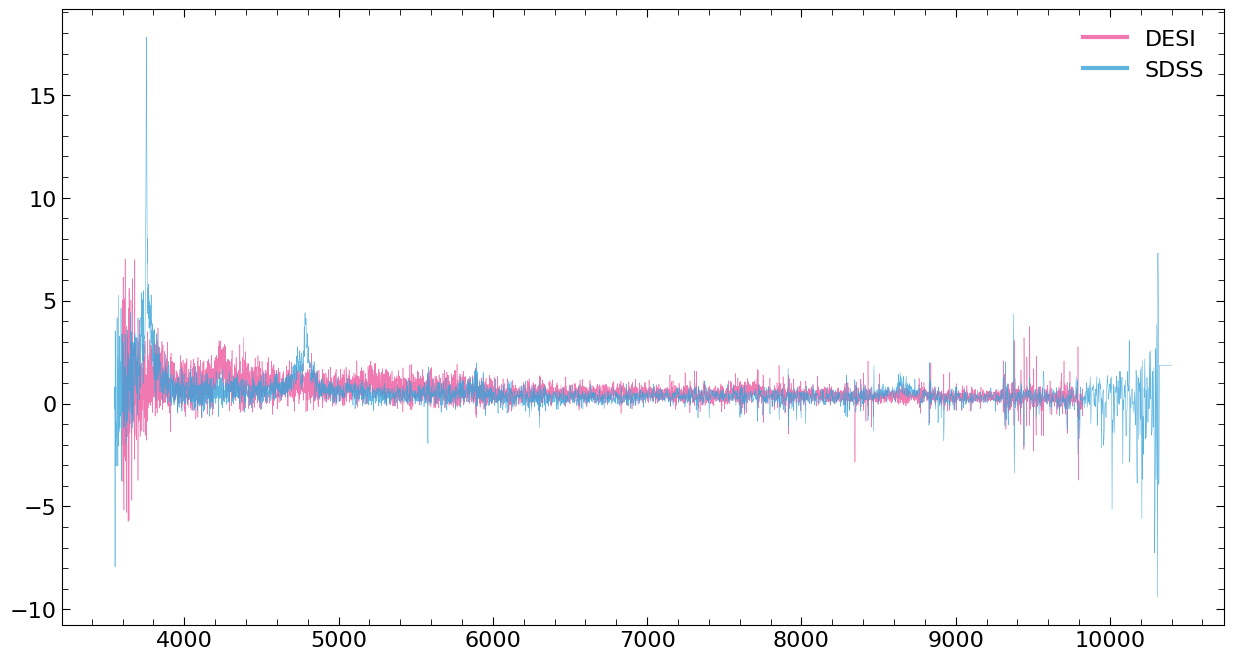

---------------------------------------
---------------------------------------

SDSS: J134026.99+083427.2


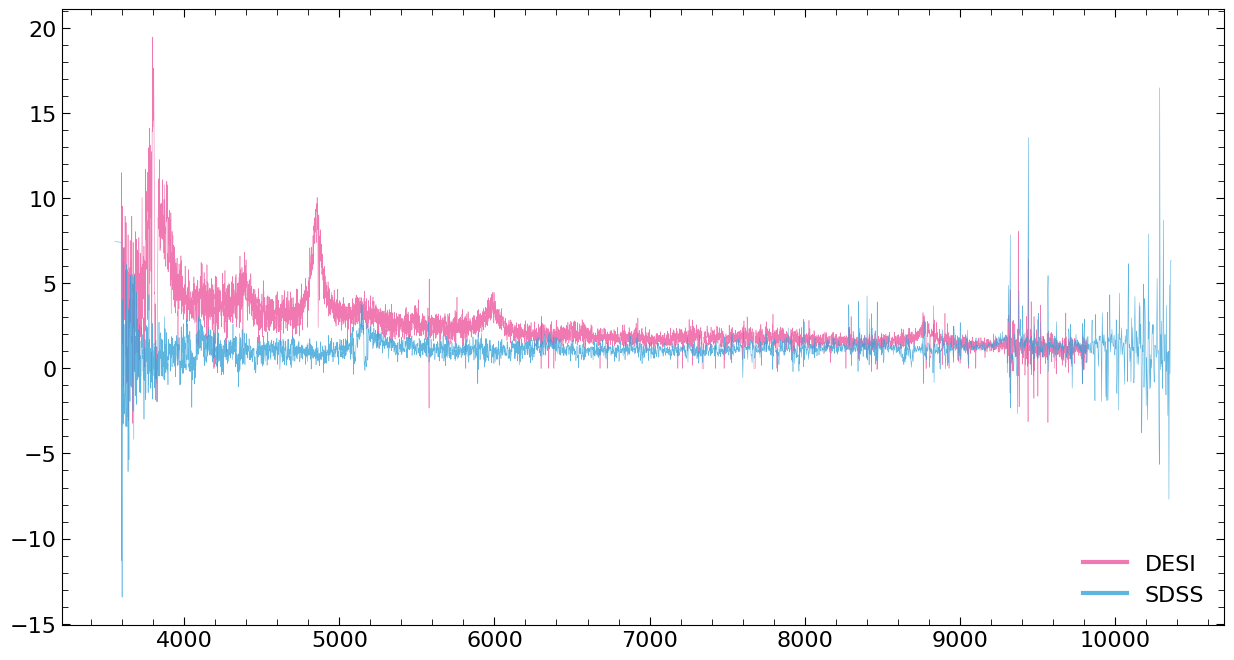

---------------------------------------
---------------------------------------

SDSS: J122000.68+064045.3


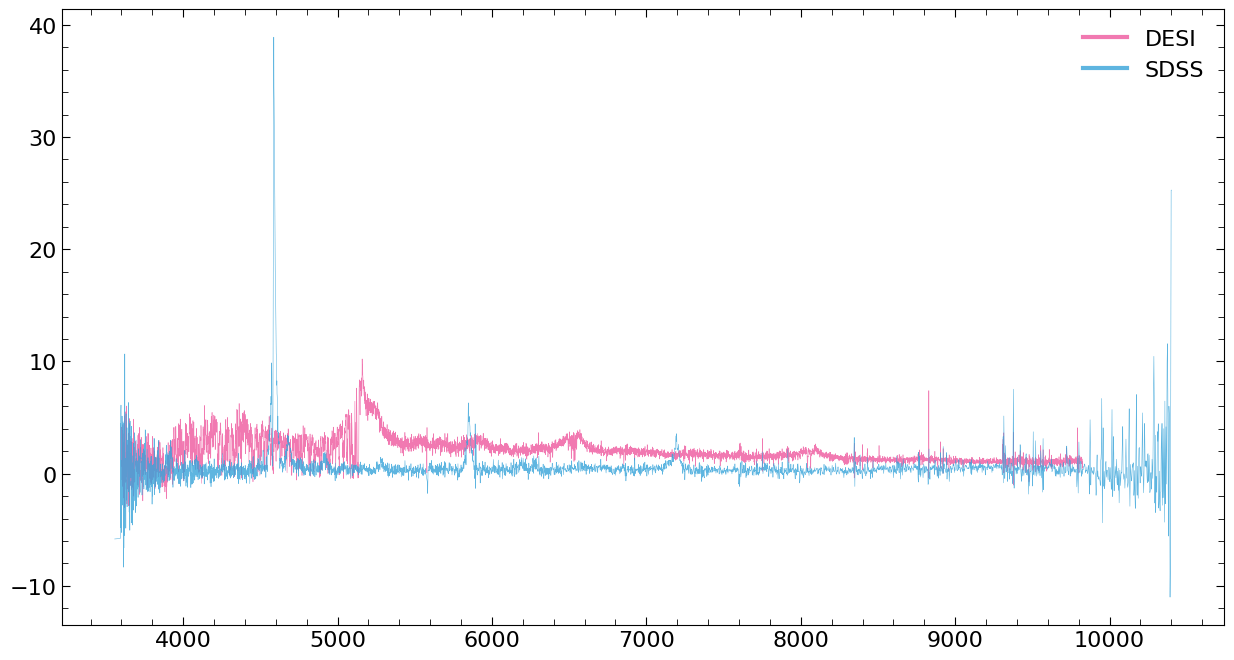

---------------------------------------
---------------------------------------

SDSS: J093506.96-024137.7


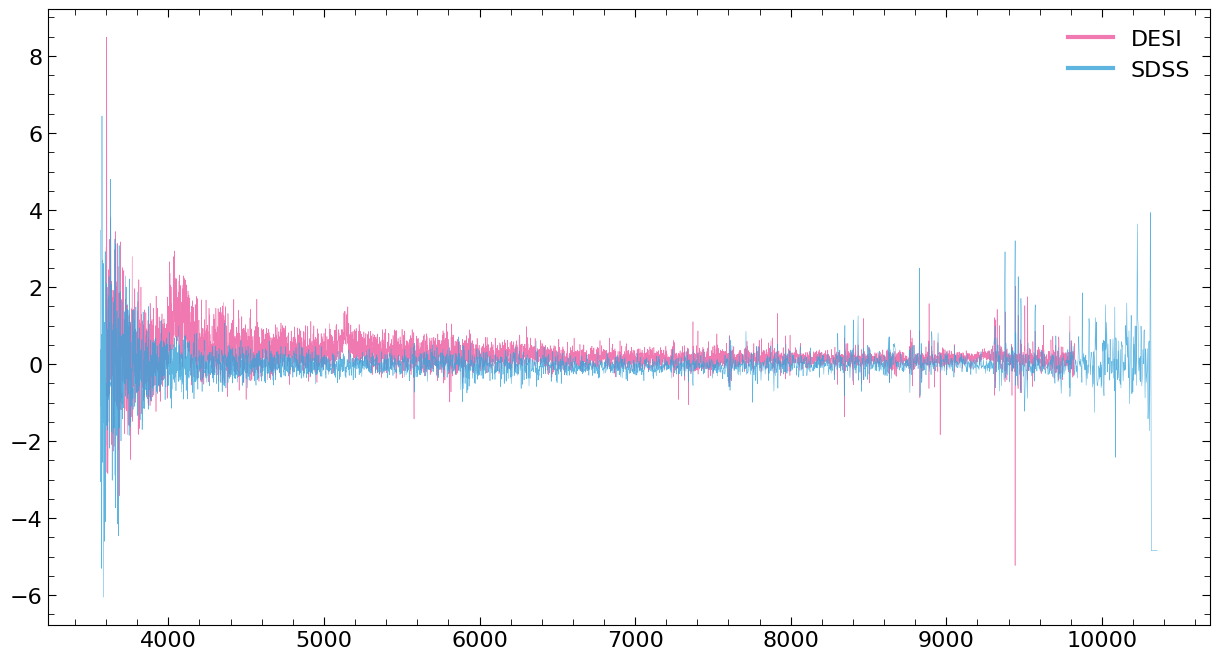

---------------------------------------
---------------------------------------

SDSS: J080547.66+454159.0


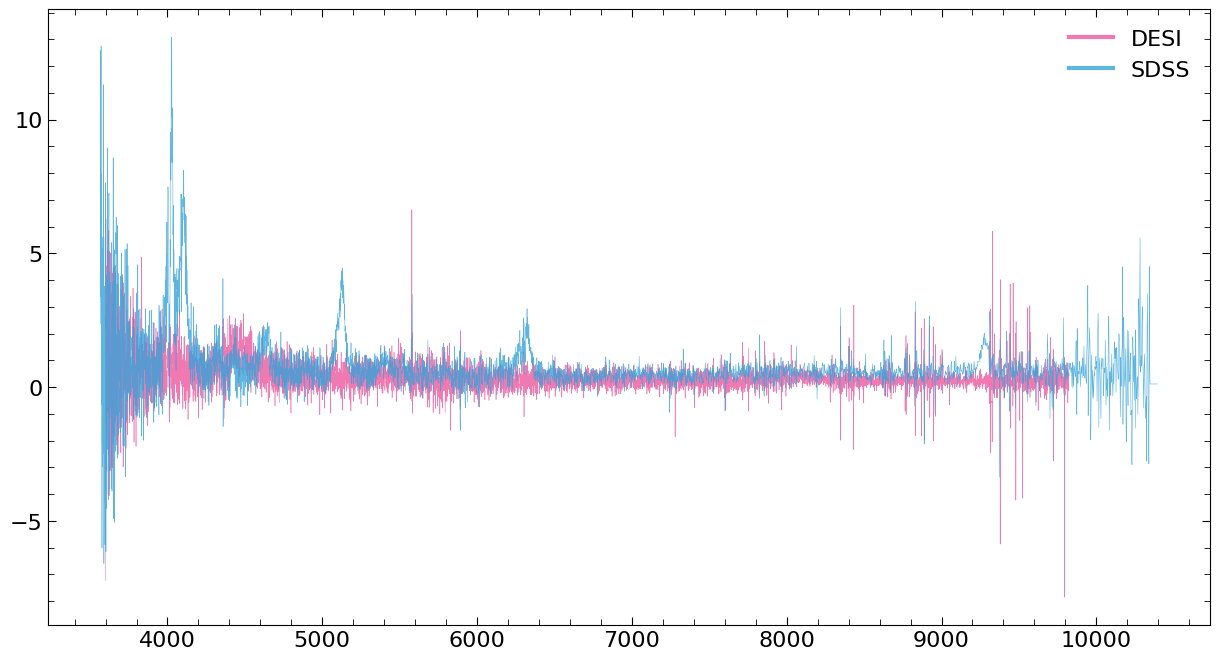

---------------------------------------
---------------------------------------

SDSS: J121704.70+023417.1


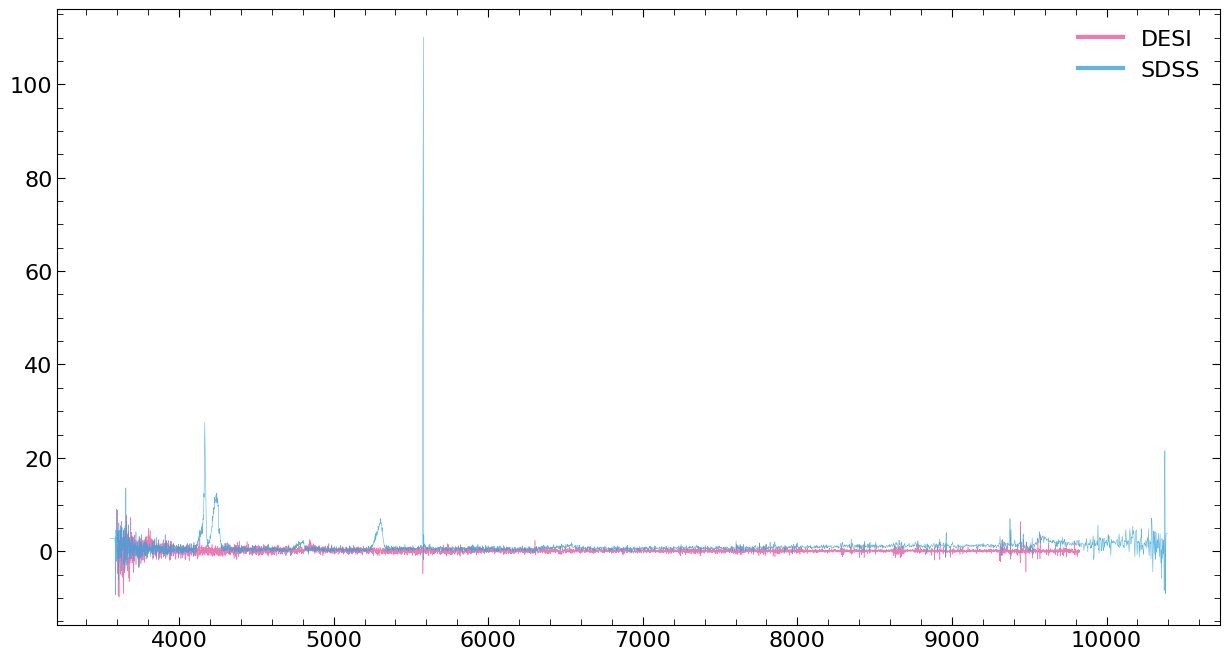

---------------------------------------
---------------------------------------

SDSS: J153108.10+213725.1


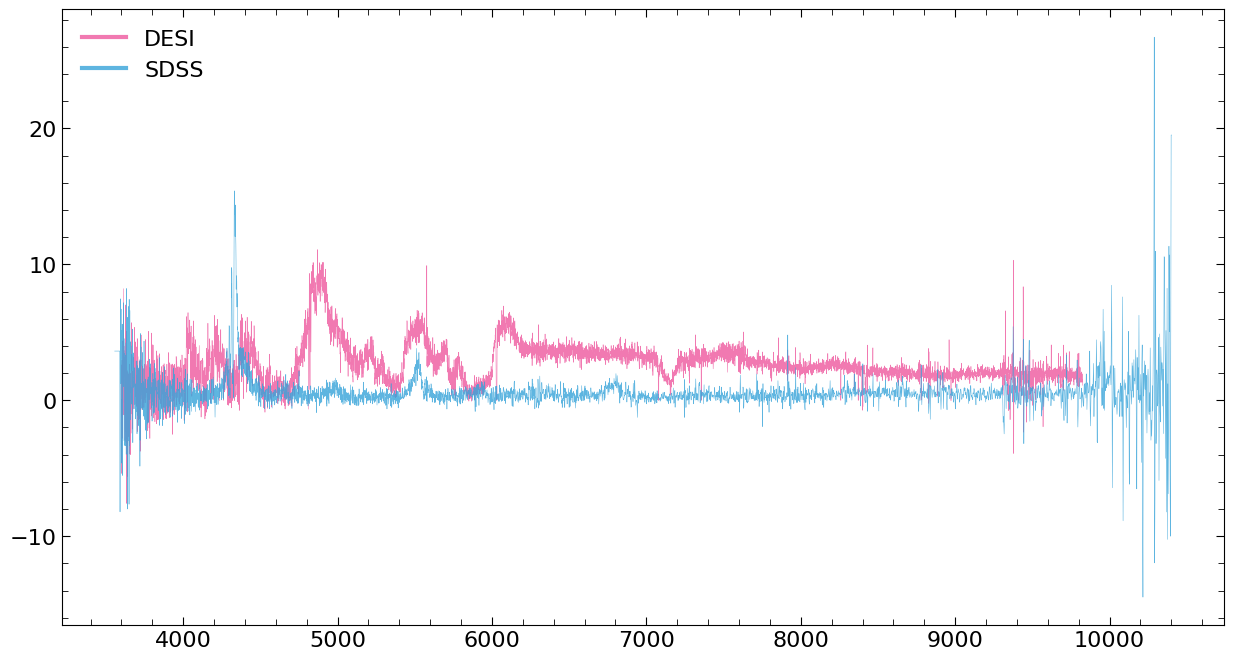

---------------------------------------
---------------------------------------

SDSS: J233636.99+065231.0


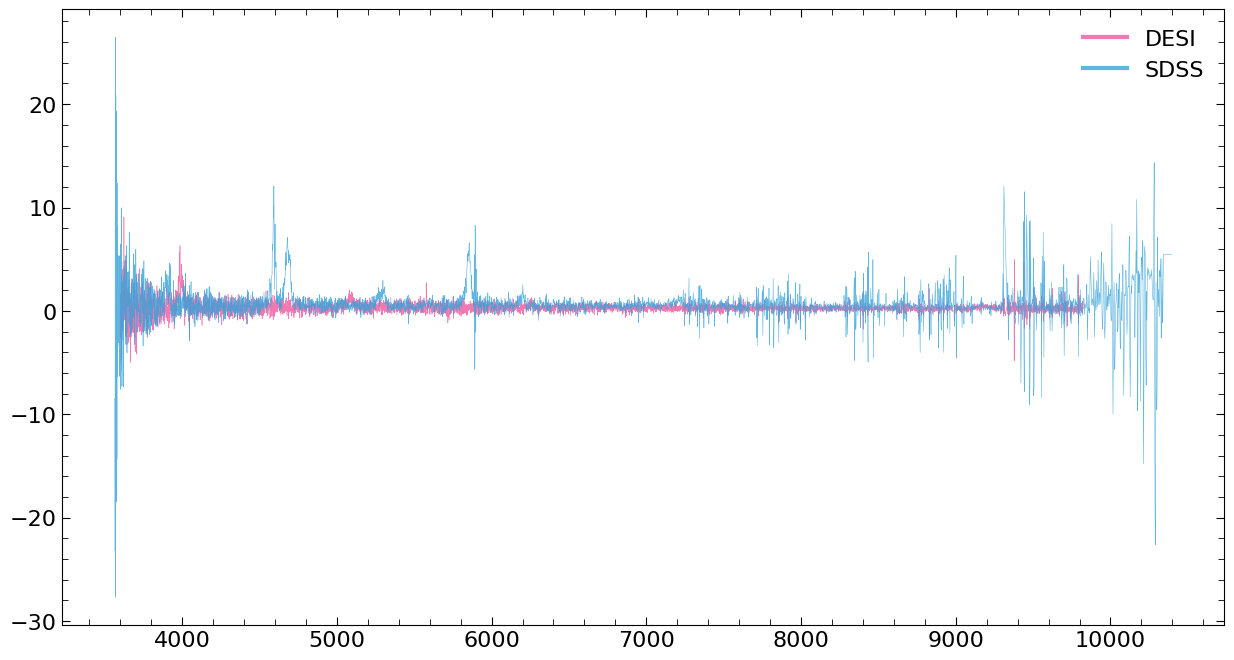

---------------------------------------
---------------------------------------

SDSS: J154831.92+311951.4


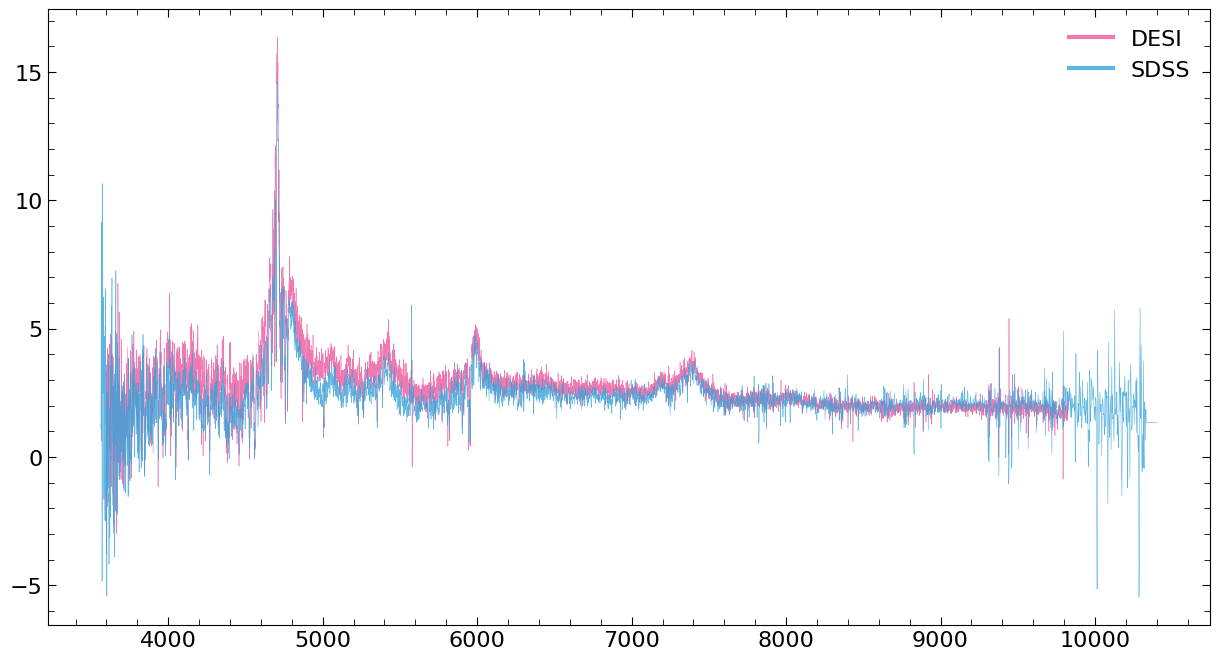

---------------------------------------
---------------------------------------

SDSS: J000610.67+121501.2


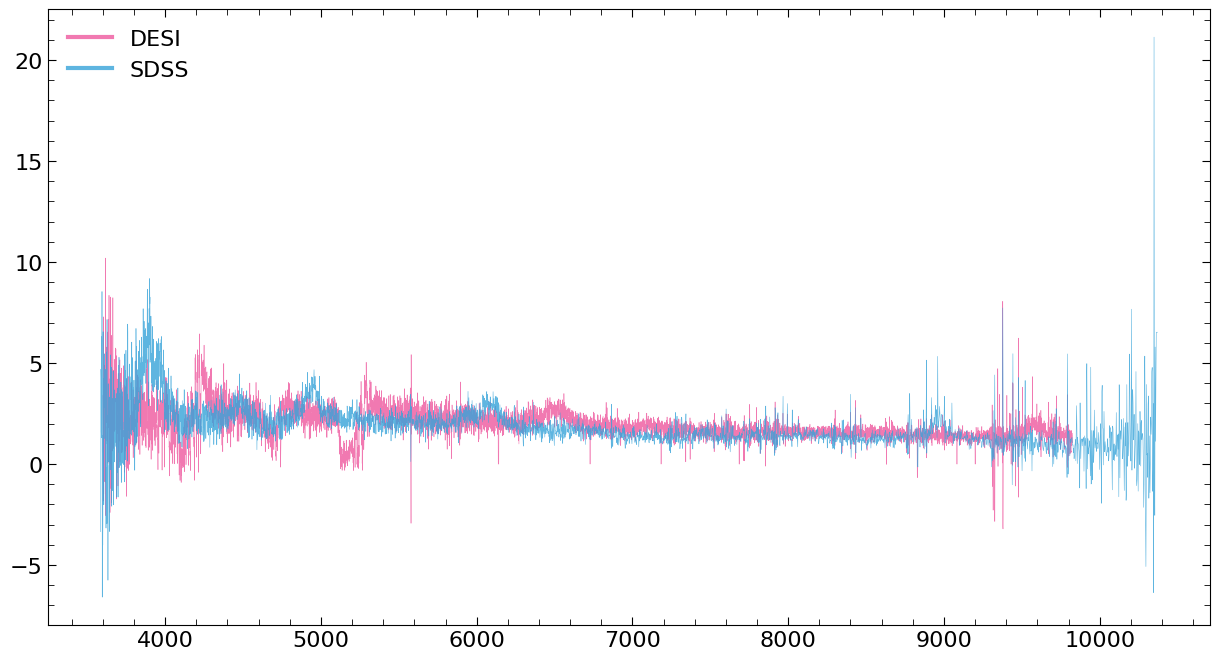

---------------------------------------
---------------------------------------

SDSS: J000746.19+122223.9


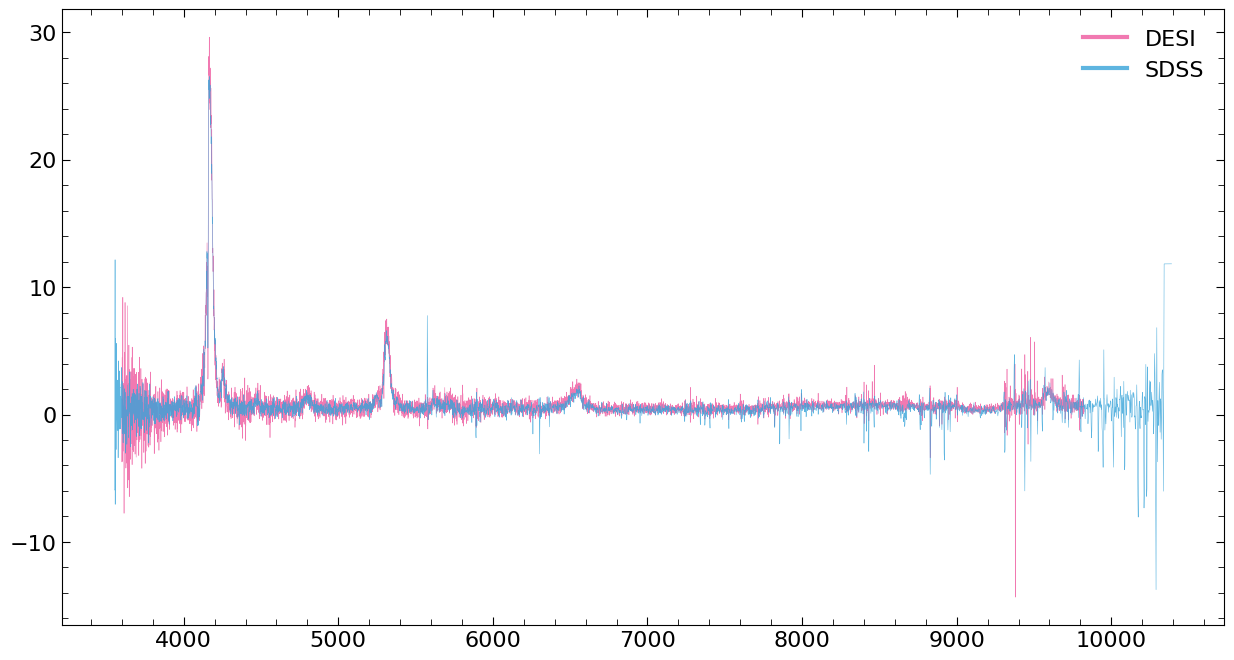

---------------------------------------
---------------------------------------

SDSS: J135608.32+073017.2


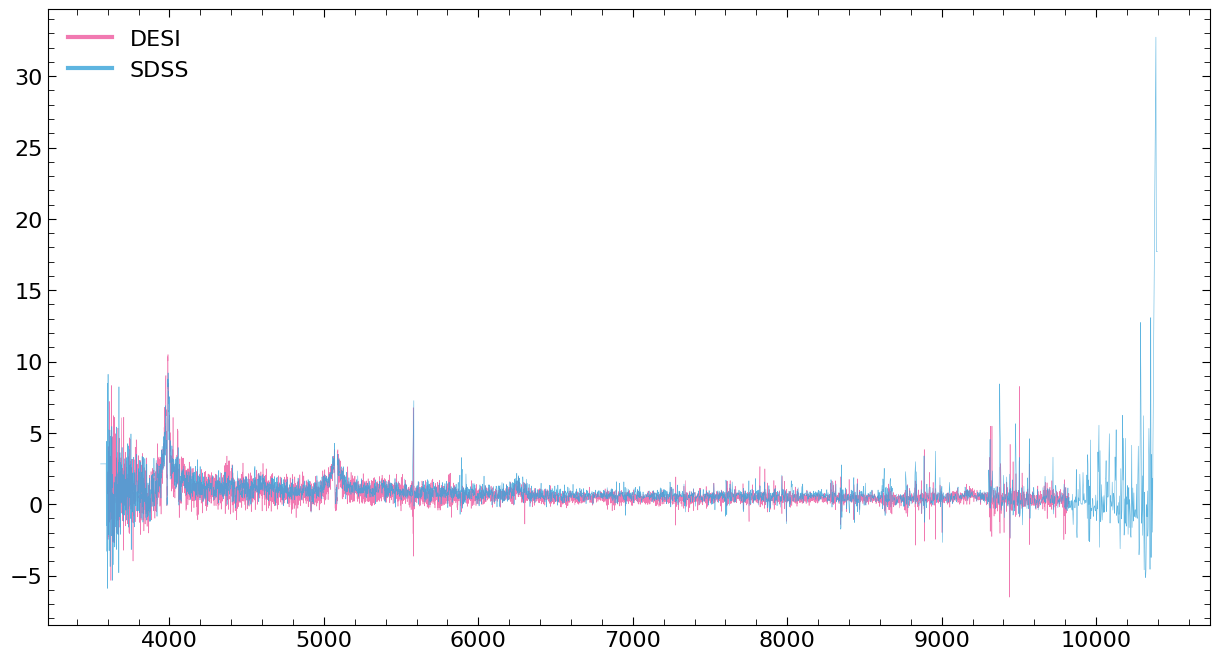

---------------------------------------
---------------------------------------

SDSS: J131722.85+322207.5


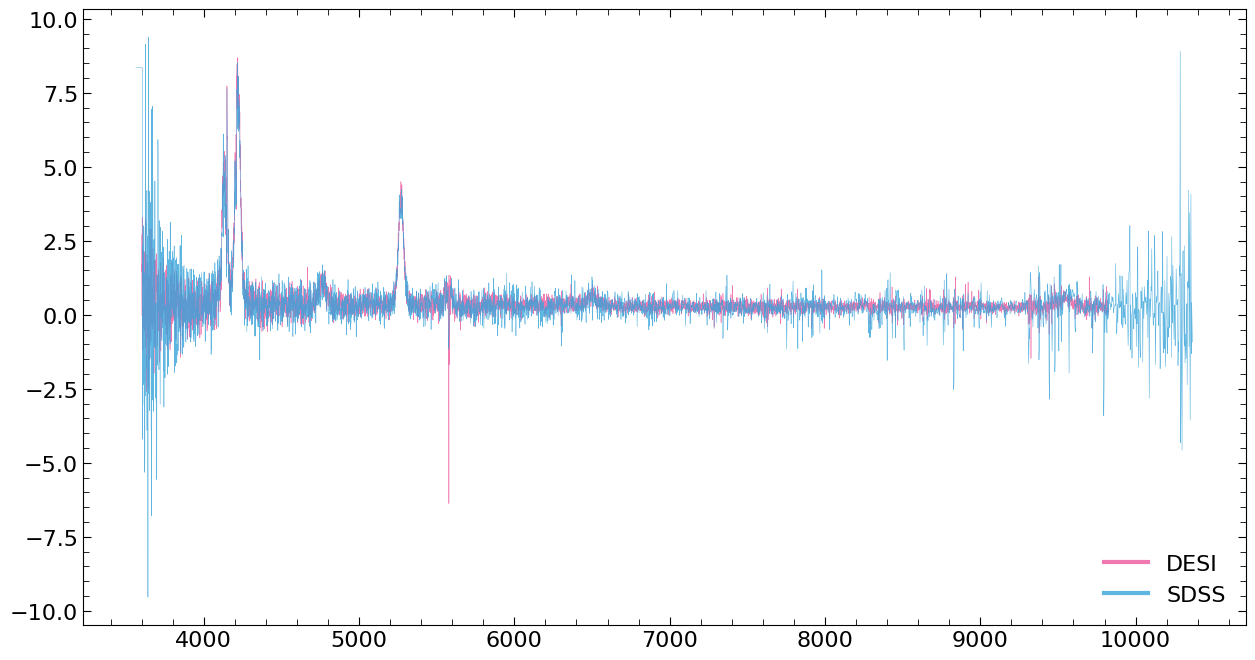

---------------------------------------
---------------------------------------

SDSS: J093638.41+101930.3


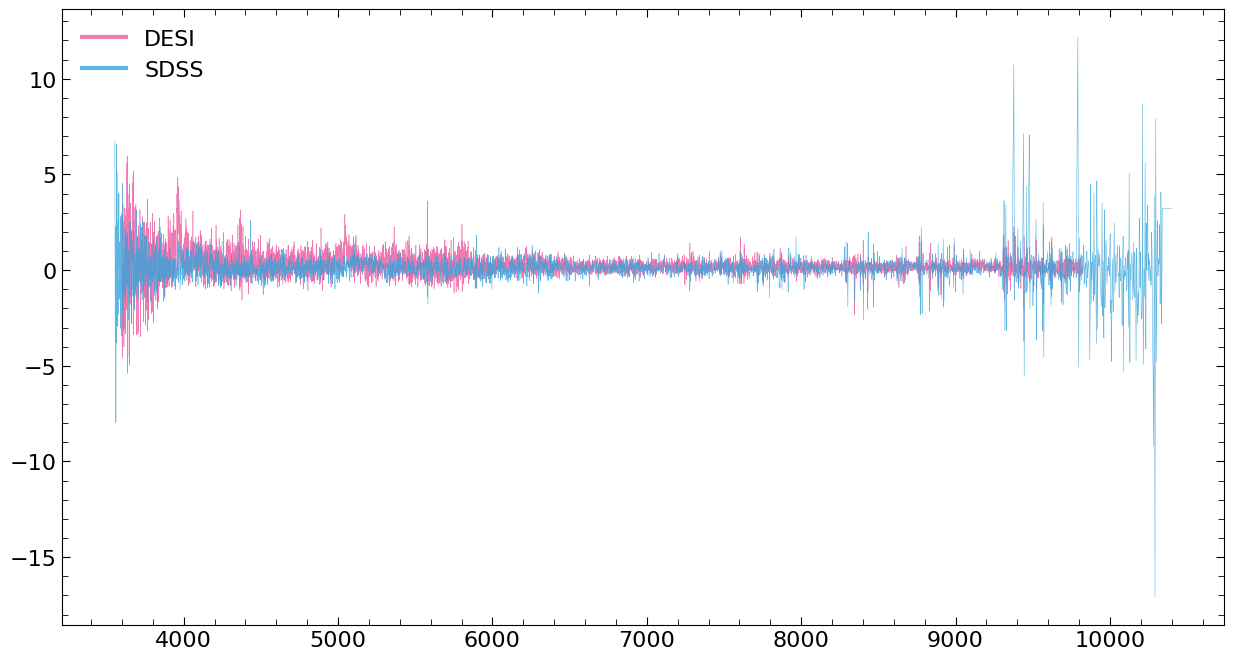

In [21]:
for i in range(len(spectra_combined)):
    desi_lam = spectra_combined["wavelength_desi"][i]
    desi_flux = spectra_combined["flux_desi"][i]
    sdss_lam = spectra_combined["wavelength_sdss"][i]
    sdss_flux = spectra_combined["flux_sdss"][i]
    sdss_id = spectra_combined["SDSS_id"][i]

    print(f"---------------------------------------\n---------------------------------------\n\nSDSS: {sdss_id}")


    plt.subplots(figsize=(15,8))

    plt.plot(desi_lam, desi_flux, color=palette_dark[0], linewidth=0.4, alpha=0.8, label="DESI")
    plt.plot(sdss_lam, sdss_flux, color=palette_dark[2], linewidth=0.4, alpha=0.8, label="SDSS")

    leg = plt.legend()

    for line in leg.get_lines():
        line.set_linewidth(3.0)

    plt.show()